In [ ]:
# Fig. 1b

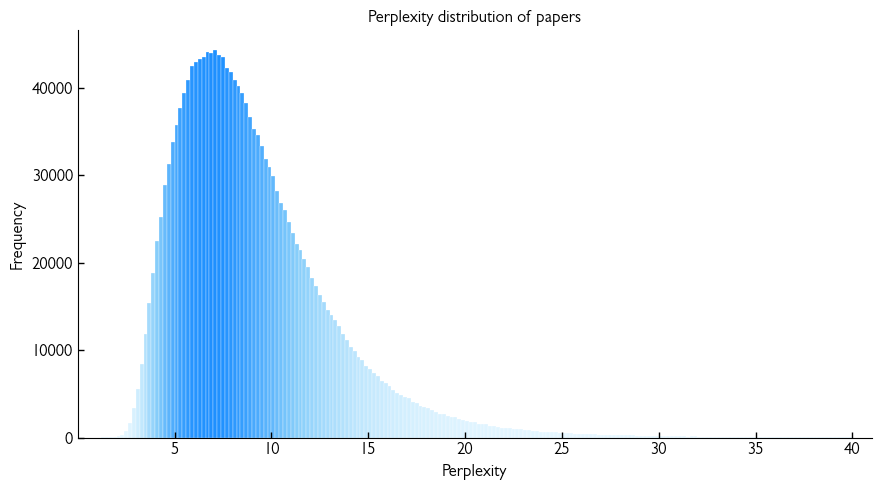

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

file_path = """./ppl_jif_citation_llama3_natural_and_social_sciences.parquet"""
# ppl_jif_citation_olmo1b_natural_and_social_sciences.parquet
# ppl_jif_citation_olmo7b_natural_and_social_sciences.parquet
# ppl_jif_citation_deepseek_natural_and_social_sciences.parquet
all_data = pd.read_parquet(file_path)

all_data = all_data[all_data['perplexity'] <= 40]

min_value = np.floor(all_data['perplexity'].min())
max_value = np.ceil(all_data['perplexity'].max())
bin_edges = np.arange(min_value, max_value + 0.2, 0.2)

counts, bins = np.histogram(all_data['perplexity'], bins=bin_edges)

light_blue = '#E6F7FF'
medium_blue = '#87CEFA'
dark_blue = '#1E90FF'
cmap = mcolors.LinearSegmentedColormap.from_list('sky_blue_gradient', [light_blue, medium_blue, dark_blue])
norm = mcolors.Normalize(vmin=0, vmax=counts.max())
colors = [cmap(norm(count)) for count in counts]

plt.figure(figsize=(9, 5))
for i in range(len(counts)):
    plt.bar(bins[i], counts[i], width=0.2, align='edge', color=colors[i], edgecolor='white', linewidth=0.2)

plt.title('Perplexity distribution of papers', fontsize=12)
plt.xlabel('Perplexity', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
ax = plt.gca()
ax.tick_params(axis='both', which='both', direction='in', length=4, width=1)
ax.tick_params(axis='both', which='major', labelsize=12)

x_ticks = ax.get_xticks()
x_labels = ax.get_xticklabels()
x_ticks_filtered = [tick for tick in x_ticks if tick != 0]
ax.set_xticks(x_ticks_filtered)

ax.tick_params(axis='y', which='major', bottom=False, top=False, left=True, right=False)
y_ticks = ax.get_yticks()
for tick in y_ticks:
    if tick == 0:
        ax.axhline(y=0, color='white', linewidth=0)

plt.grid(False)
plt.tight_layout()
plt.xlim(0, 41)
# 8. 显示图表
plt.show()

In [ ]:
# Fig. 1c

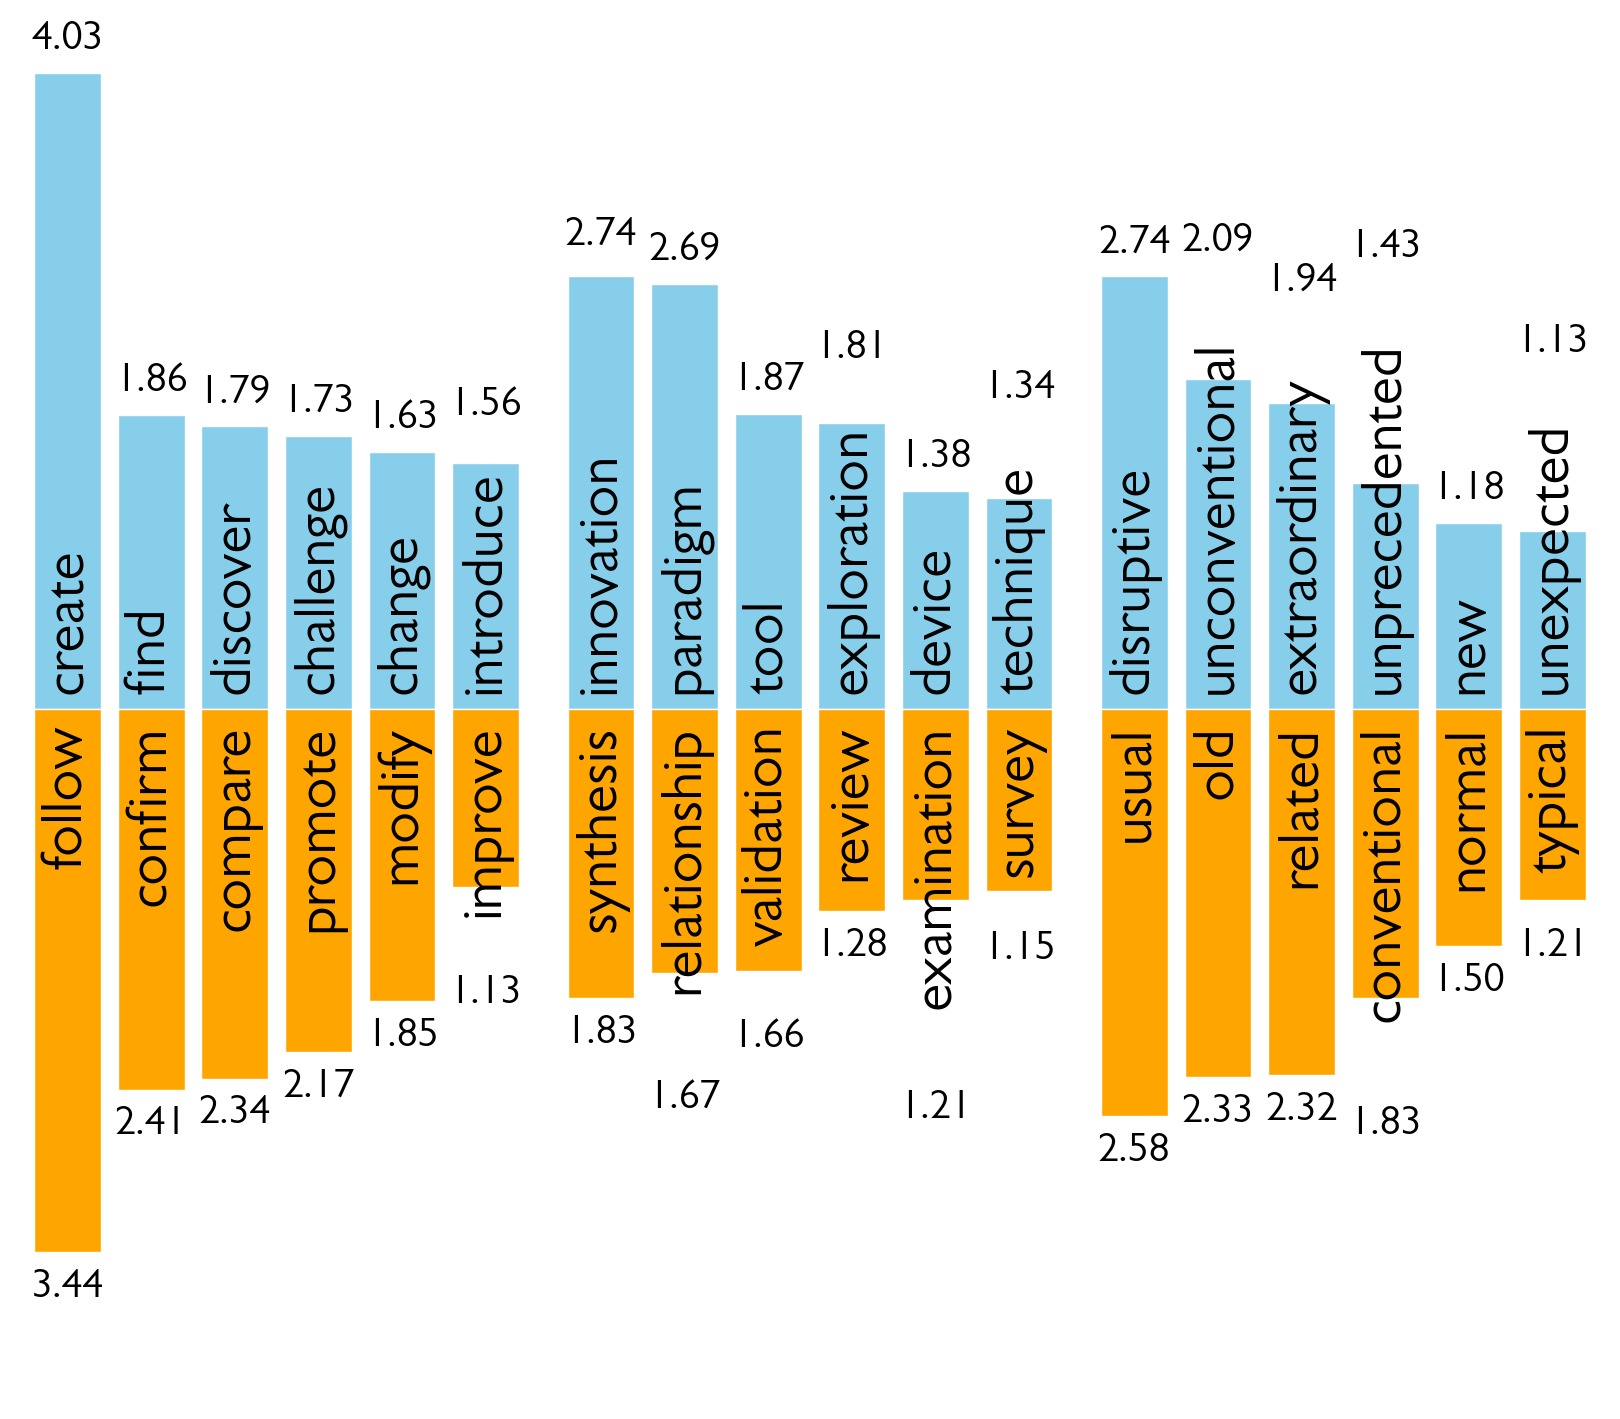

In [34]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

csv_path = './word_ratio_title.csv'
df_ratio = pd.read_csv(csv_path)

ratio_dict = dict(zip(df_ratio['word'].astype(str).str.strip().str.lower(), df_ratio['ratio']))

# Define data structure with words (values will be matched dynamically from CSV)
data_sets_words = [
    # First chart words
    {
        'words_up': ['create', 'challenge', 'change', 'discover', 'find', 'introduce'],
        'words_down': ['follow', 'modify', 'promote', 'improve', 'compare', 'confirm']
    },
    # Second chart words
    {
        'words_up': ['exploration', 'innovation', 'paradigm', 'tool', 'device', 'technique'],
        'words_down': ['relationship', 'review', 'examination', 'survey', 'validation', 'synthesis']
    },
    # Third chart words
    {
        'words_up': ['new', 'extraordinary', 'unconventional', 'unprecedented', 'unexpected', 'disruptive'],
        'words_down': ['usual', 'related', 'conventional', 'typical', 'normal', 'old']
    }
]

# Populate values_up and values_down from ratio_dict
data_sets = []
for d in data_sets_words:
    words_up = d['words_up']
    words_down = d['words_down']

    values_up = []
    for w in words_up:
        val = ratio_dict.get(w.lower())
        if val is None:
            print(f"Warning: Word '{w}' not found in CSV! Setting ratio to 0.0")
            val = 0.0
        values_up.append(float(val))
        
    values_down = []
    for w in words_down:
        val = ratio_dict.get(w.lower())
        if val is None:
            print(f"Warning: Word '{w}' not found in CSV! Setting ratio to 0.0")
            val = 0.0
        values_down.append(float(val))
        
    data_sets.append({
        'words_up': words_up,
        'values_up': values_up,
        'words_down': words_down,
        'values_down': values_down
    })

# Create a figure with a 1x3 grid layout (horizontal arrangement)
plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1])

# Find the global maximum value across all datasets
global_max_value = 0
for data in data_sets:
    max_up = max(data['values_up'][:len(data['words_up'])]) if data['values_up'] else 0
    max_down = max(data['values_down']) if data['values_down'] else 0
    dataset_max = max(max_up, max_down)
    if dataset_max > global_max_value:
        global_max_value = dataset_max

# Create and populate each subplot
for i, data in enumerate(data_sets):
    # Extract data
    words_up = data['words_up']
    values_up = data['values_up']
    words_down = data['words_down']
    values_down = data['values_down']
    
    # Fix the length issue in the first dataset if necessary
    if len(values_up) > len(words_up):
        values_up = values_up[:len(words_up)]
    
    # Combine up and down data, sort each separately by value
    sorted_up_data = sorted(zip(values_up, words_up), reverse=True)
    sorted_up_values, sorted_up_words = zip(*sorted_up_data)
    
    sorted_down_data = sorted(zip(values_down, words_down), reverse=True)
    sorted_down_values, sorted_down_words = zip(*sorted_down_data)
    
    # Create the subplot
    ax = plt.subplot(gs[i])
    
    # Bar width
    bar_width = 0.8
    
    # Create x positions for 6 bars
    x_positions = range(6)
    
    # Create bars - upward bars with positive values, downward bars with negative values
    bars_up = ax.bar(x_positions, sorted_up_values, width=bar_width, color='skyblue')
    bars_down = ax.bar(x_positions, [-v for v in sorted_down_values], width=bar_width, color='orange')
    
    # Define fixed heights for word labels
    word_label_height_up = 0.1   # Fixed height above x-axis for upward bar words
    word_label_height_down = -0.1 # Fixed height below x-axis for downward bar words
    value_offset = 0.1           # Offset for values above/below bars
    
    # Add word labels and value labels for upward bars
    for idx, (bar, word, value) in enumerate(zip(bars_up, sorted_up_words, sorted_up_values)):
        # Add word at fixed height above x-axis (bottom of bar)
        ax.text(idx, word_label_height_up, word,
                ha='center', va='bottom', color='black', fontsize=42, rotation=90, fontweight='bold')
        
        # Special positioning for specific words
        if word == 'technique':
            value_position = value + 0.58
        elif word == 'exploration':
            value_position = value + 0.36
        elif word == 'unconventional':
            value_position = value + 0.76
        elif word == 'unprecedented':
            value_position = value + 1.38
        elif word == 'innovation':
            value_position = value + 0.15
        elif word == 'unexpected':
            value_position = value + 1.08
        elif word == 'introduce':
            value_position = value + 0.25
        elif word == 'extraordinary':
            value_position = value + 0.66
        else:
            value_position = value + value_offset
            
        # Add value above the bar (no rotation)
        ax.text(idx, value_position, f'{value:.2f}',
                ha='center', va='bottom', color='black', fontsize=30)
    
    # Add word labels and value labels for downward bars
    for idx, (bar, word, value) in enumerate(zip(bars_down, sorted_down_words, sorted_down_values)):
        # Add word at fixed height below x-axis (bottom of bar)
        ax.text(idx, word_label_height_down, word,
                ha='center', va='top', color='black', fontsize=42, rotation=90, fontweight='bold')
        
        # Special positioning for specific words
        if word == 'examination':
            value_position = -value - 1.2
        elif word == 'synthesis':
            value_position = -value - value_offset
        elif word == 'conventional':
            value_position = -value - 0.68
        elif word == 'relationship':
            value_position = -value - 0.68
        elif word == 'improve':
            value_position = -value - 0.55
        elif word == 'validation':
            value_position = -value - 0.3
        elif word == 'survey':
            value_position = -value - 0.25
        elif word == 'typical':
            value_position = -value - 0.17
        else:
            value_position = -value - value_offset
            
        # Add value below the bar (no rotation)
        ax.text(idx, value_position, f'{value:.2f}',
                ha='center', va='top', color='black', fontsize=30)
    
    # Remove axes and ticks
    ax.axis('off')
    
    # Use the global maximum value to set consistent y-limits across all plots
    ax.set_ylim(-global_max_value * 1.1, global_max_value * 1.1)

# Adjust layout to prevent overlap
plt.tight_layout(pad=0)
# Display the chart
plt.show()

In [ ]:
# Fig. 2a

/home/zhenzhang/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/scratch/local/jobs/59349233/ipykernel_1240957/209451044.py:324: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


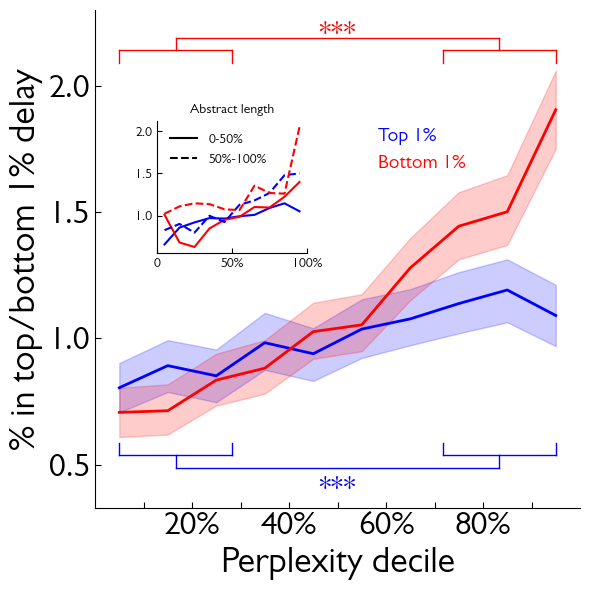

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.lines import Line2D
import matplotlib.font_manager as fm

def bootstrap_ci(data, statistic, n_bootstraps=1000, ci=0.95):
    """
    Calculate bootstrap confidence interval for a statistic.
    
    Parameters:
    -----------
    data : array-like
        The data to resample
    statistic : function
        The statistic to compute (e.g., np.mean, np.median)
    n_bootstraps : int
        Number of bootstrap resamples
    ci : float
        Confidence interval (0 to 1)
    
    Returns:
    --------
    tuple : (lower bound, upper bound)
    """
    bootstrap_samples = []
    for _ in range(n_bootstraps):
        sample = np.random.choice(data, size=len(data), replace=True)
        bootstrap_samples.append(statistic(sample))
    
    alpha = (1 - ci) / 2
    lower_bound = np.percentile(bootstrap_samples, 100 * alpha)
    upper_bound = np.percentile(bootstrap_samples, 100 * (1 - alpha))
    
    return lower_bound, upper_bound


file_path = "./doi_delay.parquet"
df = pd.read_parquet(file_path)

top_1_percent_threshold = df['days_difference'].quantile(0.99)
bottom_1_percent_threshold = df['days_difference'].quantile(0.01)

df['perplexity_bin'], bins = pd.qcut(df['perplexity'], q=10, retbins=True, precision=2)

percentages_top = []
percentages_bottom = []
ci_lower_top = []
ci_upper_top = []
ci_lower_bottom = []
ci_upper_bottom = []
combined_percentages = []

n_bootstraps = 1000

for i in range(10):
    lower_bound = bins[i]
    upper_bound = bins[i + 1]

    subset = df[(df['perplexity'] >= lower_bound) & (df['perplexity'] < upper_bound)]
    
    if len(subset) == 0:
        mid_percent = (i * 10 + (i + 1) * 10) / 2
        percentages_top.append((mid_percent, 0))
        percentages_bottom.append((mid_percent, 0))
        ci_lower_top.append(0)
        ci_upper_top.append(0)
        ci_lower_bottom.append(0)
        ci_upper_bottom.append(0)
        combined_percentages.append(0)
        continue

    top_1_percent = subset[subset['days_difference'] >= top_1_percent_threshold]
    bottom_1_percent = subset[subset['days_difference'] <= bottom_1_percent_threshold]

    percentage_top = len(top_1_percent) / len(subset) * 100
    percentage_bottom = len(bottom_1_percent) / len(subset) * 100
    
    is_top_1_percent = (subset['days_difference'] >= top_1_percent_threshold).astype(int) * 100
    is_bottom_1_percent = (subset['days_difference'] <= bottom_1_percent_threshold).astype(int) * 100
    
    top_ci_lower, top_ci_upper = bootstrap_ci(is_top_1_percent, np.mean, n_bootstraps=n_bootstraps)
    bottom_ci_lower, bottom_ci_upper = bootstrap_ci(is_bottom_1_percent, np.mean, n_bootstraps=n_bootstraps)
    
    mid_percent = (i * 10 + (i + 1) * 10) / 2
    percentages_top.append((mid_percent, percentage_top))
    percentages_bottom.append((mid_percent, percentage_bottom))
    ci_lower_top.append(top_ci_lower)
    ci_upper_top.append(top_ci_upper)
    ci_lower_bottom.append(bottom_ci_lower)
    ci_upper_bottom.append(bottom_ci_upper)
    combined_percentage = percentage_top + percentage_bottom
    combined_percentages.append(combined_percentage)

x_values = [x[0] for x in percentages_top]
y_values_top = [x[1] for x in percentages_top]
y_values_bottom = [x[1] for x in percentages_bottom]

fig, ax1 = plt.subplots(figsize=(6, 6))

ax1.plot(
    x_values, y_values_top, color='b',
    linewidth=2, markersize=8
)
ax1.fill_between(
    x_values,
    np.array(ci_lower_top),
    np.array(ci_upper_top),
    color='blue', alpha=0.2
)

ax1.plot(
    x_values, y_values_bottom, color='r',
    linewidth=2, markersize=8
)
ax1.fill_between(
    x_values,
    np.array(ci_lower_bottom),
    np.array(ci_upper_bottom),
    color='red', alpha=0.2
)

all_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
ax1.set_xticks(all_ticks)
ax1.set_xticklabels([
    "20%" if i == 20 else
    "40%" if i == 40 else
    "60%" if i == 60 else
    "80%" if i == 80 else
    ""
    for i in all_ticks
])
ax1.set_xlim(0, 100)

ax1.set_xlabel("Perplexity decile", fontsize=26)
ax1.set_ylabel("% in top/bottom 1% delay", fontsize=26)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(False)

upper_left_bracket_width = 23.33
upper_right_bracket_width = 23.33
upper_bracket_height = 0.05
upper_top_bracket_height = 0.25
upper_vertical_gap = 0

lower_left_bracket_width = 23.33
lower_right_bracket_width = 23.33
lower_bracket_height = 0.05
lower_top_bracket_height = 0.05
lower_vertical_gap = 0

y_max_bottom = max(max(y_values_bottom), max(ci_upper_bottom))
y_base_upper = y_max_bottom + 0.03

y_min_top = min(min(y_values_top), min(ci_lower_top))
y_base_lower = y_min_top - 0.12

x_left_center = 16.665
x_right_center = 83.335

x_left_start = x_left_center - upper_left_bracket_width/2
x_left_end = x_left_center + upper_left_bracket_width/2
x_right_start = x_right_center - upper_right_bracket_width/2
x_right_end = x_right_center + upper_right_bracket_width/2

ax1.plot([x_left_start, x_left_start], [y_base_upper, y_base_upper + upper_bracket_height], linewidth=1, color='red')
ax1.plot([x_left_start, x_left_end], [y_base_upper + upper_bracket_height, y_base_upper + upper_bracket_height], linewidth=1, color='red')
ax1.plot([x_left_end, x_left_end], [y_base_upper + upper_bracket_height, y_base_upper], linewidth=1, color='red')

ax1.plot([x_right_start, x_right_start], [y_base_upper, y_base_upper + upper_bracket_height], linewidth=1, color='red')
ax1.plot([x_right_start, x_right_end], [y_base_upper + upper_bracket_height, y_base_upper + upper_bracket_height], linewidth=1, color='red')
ax1.plot([x_right_end, x_right_end], [y_base_upper + upper_bracket_height, y_base_upper], linewidth=1, color='red')

y_top_base_upper = y_base_upper + upper_bracket_height + upper_vertical_gap
y_top_top_upper = y_top_base_upper + upper_top_bracket_height - 0.2

ax1.plot([x_left_center, x_left_center], [y_base_upper + upper_bracket_height, y_top_base_upper], linewidth=1, color='red')
ax1.plot([x_right_center, x_right_center], [y_base_upper + upper_bracket_height, y_top_base_upper], linewidth=1, color='red')

ax1.plot([x_left_center, x_left_center], [y_top_base_upper, y_top_top_upper], linewidth=1, color='red')
ax1.plot([x_left_center, x_right_center], [y_top_top_upper, y_top_top_upper], linewidth=1, color='red')
ax1.plot([x_right_center, x_right_center], [y_top_top_upper, y_top_base_upper], linewidth=1, color='red')

ax1.text((x_left_center + x_right_center) / 2, y_top_top_upper - 0.05, "***", 
        ha='center', va='bottom', fontsize=24, color='red')

x_left_start_lower = x_left_center - lower_left_bracket_width/2
x_left_end_lower = x_left_center + lower_left_bracket_width/2
x_right_start_lower = x_right_center - lower_right_bracket_width/2
x_right_end_lower = x_right_center + lower_right_bracket_width/2

ax1.plot([x_left_start_lower, x_left_start_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')
ax1.plot([x_left_start_lower, x_left_end_lower], [y_base_lower - lower_bracket_height, y_base_lower - lower_bracket_height], linewidth=1, color='blue')
ax1.plot([x_left_end_lower, x_left_end_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')

ax1.plot([x_right_start_lower, x_right_start_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')
ax1.plot([x_right_start_lower, x_right_end_lower], [y_base_lower - lower_bracket_height, y_base_lower - lower_bracket_height], linewidth=1, color='blue')
ax1.plot([x_right_end_lower, x_right_end_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')

y_top_base_lower = y_base_lower - lower_bracket_height - lower_vertical_gap
y_top_top_lower = y_top_base_lower - lower_top_bracket_height

ax1.plot([x_left_center, x_left_center], [y_base_lower - lower_bracket_height, y_top_base_lower], linewidth=1, color='blue')
ax1.plot([x_right_center, x_right_center], [y_base_lower - lower_bracket_height, y_top_base_lower], linewidth=1, color='blue')

ax1.plot([x_left_center, x_left_center], [y_top_base_lower, y_top_top_lower], linewidth=1, color='blue')
ax1.plot([x_left_center, x_right_center], [y_top_top_lower, y_top_top_lower], linewidth=1, color='blue')
ax1.plot([x_right_center, x_right_center], [y_top_top_lower, y_top_base_lower], linewidth=1, color='blue')

ax1.text((x_left_center + x_right_center) / 2, y_top_top_lower - 0.03, "***", 
        ha='center', va='top', fontsize=24, color='blue')

ax1.legend(
    handles=[
        Line2D([0], [0], color='blue', lw=0),
        Line2D([0], [0], color='red', lw=0)
    ],
    labels=['Top 1%', 'Bottom 1%'],
    fontsize=14,
    bbox_to_anchor=(0.8, 0.8),
    loc='upper right',
    frameon=False,
    ncol=1,
    labelcolor=['blue', 'red']
)

ax1.tick_params(axis='both', direction='in', length=4)
ax1.tick_params(axis='both', labelsize=24)
ax1.set_ylim(0.33, 2.3)

left, bottom, width, height = 0.27, 0.57, 0.25, 0.22
ax_inset = fig.add_axes([left, bottom, width, height])

df['token_group'] = pd.qcut(df['num_token'], q=2, labels=['0-50%', '50%-100%'])

colors = ['b', 'r']
line_styles = ['-', '--']

for group_idx, group_name in enumerate(['0-50%', '50%-100%']):
    group_df = df[df['token_group'] == group_name]
    
    group_top_threshold = group_df['days_difference'].quantile(0.99)
    group_bottom_threshold = group_df['days_difference'].quantile(0.01)
    
    group_percentages_top = []
    group_percentages_bottom = []
    
    for i in range(10):
        lower_bound = bins[i]
        upper_bound = bins[i + 1]
        
        subset = group_df[(group_df['perplexity'] >= lower_bound) & (group_df['perplexity'] < upper_bound)]
        
        if len(subset) == 0:
            mid_percent = (i * 10 + (i + 1) * 10) / 2
            group_percentages_top.append((mid_percent, 0))
            group_percentages_bottom.append((mid_percent, 0))
            continue
        
        top_1_percent = subset[subset['days_difference'] >= group_top_threshold]
        bottom_1_percent = subset[subset['days_difference'] <= group_bottom_threshold]
        
        percentage_top = len(top_1_percent) / len(subset) * 100
        percentage_bottom = len(bottom_1_percent) / len(subset) * 100
        
        mid_percent = (i * 10 + (i + 1) * 10) / 2
        group_percentages_top.append((mid_percent, percentage_top))
        group_percentages_bottom.append((mid_percent, percentage_bottom))
    
    x_values_group = [x[0] for x in group_percentages_top]
    y_values_top_group = [x[1] for x in group_percentages_top]
    y_values_bottom_group = [x[1] for x in group_percentages_bottom]
    
    ax_inset.plot(
        x_values_group, y_values_top_group, 
        color=colors[0], 
        linestyle=line_styles[group_idx],
        linewidth=1.5
    )
    
    ax_inset.plot(
        x_values_group, y_values_bottom_group, 
        color=colors[1], 
        linestyle=line_styles[group_idx],
        linewidth=1.5
    )

ax_inset.set_xticks(range(0, 110, 50))
ax_inset.set_xticklabels(["0", "50%", "100%"], fontsize=10)
ax_inset.set_title("Abstract length", fontsize=10)
ax_inset.tick_params(axis='both', which='major', labelsize=10)
ax_inset.tick_params(axis='both', direction='in')
ax_inset.grid(False)
ax_inset.spines['right'].set_visible(False)
ax_inset.spines['top'].set_visible(False)

ax_inset.legend(
    handles=[
        Line2D([0], [0], color='black', linestyle='-', linewidth=1.5),
        Line2D([0], [0], color='black', linestyle='--', linewidth=1.5)
    ],
    labels=['0-50%', '50%-100%'],
    fontsize=10, 
    frameon=False, 
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [ ]:
# Fig. 2b

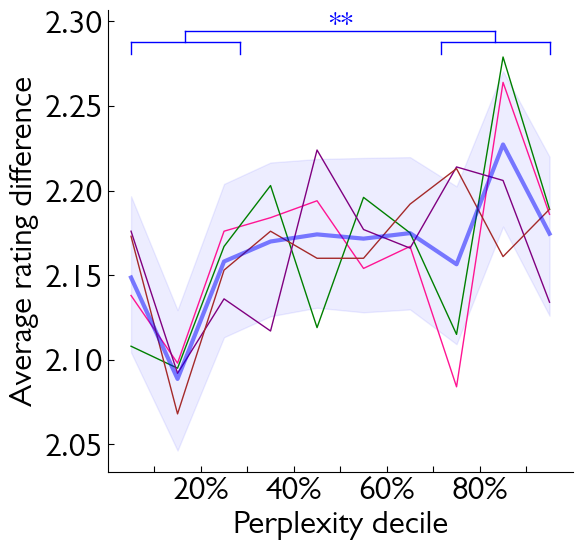

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import matplotlib.font_manager as fm

file_paths = [
    './openreview_olmo1b_ppl_rating_confidence_rating-disparity.parquet',
    './openreview_olmo7b_ppl_rating_confidence_rating-disparity.parquet',
    './openreview_llama3_ppl_rating_confidence_rating-disparity.parquet',
    './openreview_deepseek_ppl_rating_confidence_rating-disparity.parquet'
]
file_labels = ['OLMo-1B', 'OLMo-7B', 'Llama-3-8B', 'DeepSeek-llm-7B'] # , 'Llama-2-7B'
color_map = {
    'OLMo-1B': 'deeppink',
    'OLMo-7B': 'green',
    'Llama-3-8B': 'purple',
    'DeepSeek-llm-7B': 'brown'
}

fig, ax = plt.subplots(figsize=(6, 6))
all_data = []

for file_idx, (file_path, label) in enumerate(zip(file_paths, file_labels)):
    df = pd.read_parquet(file_path)
    df['model'] = label
    df['perplexity_group'] = pd.qcut(df['perplexity'], q=10, labels=False)
    all_data.append(df)
    group_stats = df.groupby('perplexity_group').agg({
        'rating_max-min': ['mean', 'std'],
        'perplexity': ['min', 'max']
    }).round(3)
    x_values = [(i + 0.5) * 10 for i in range(10)]
    y_values = group_stats['rating_max-min']['mean']
    ax.plot(x_values, y_values, linewidth=1, markersize=8, alpha=1, color=color_map[label])

combined_data = pd.concat(all_data, ignore_index=True)

x_values = [(i + 0.5) * 10 for i in range(10)]

weighted_avg = np.zeros(10)
for i in range(10):
    bin_data = combined_data[combined_data['perplexity_group'] == i]
    if not bin_data.empty:
        weighted_avg[i] = bin_data['rating_max-min'].mean()

n_bootstraps = 1000
bootstrap_results = np.zeros((n_bootstraps, 10))

for b in range(n_bootstraps):
    for i in range(10):
        bin_data = combined_data[combined_data['perplexity_group'] == i]
        if len(bin_data) > 0:
            bootstrap_sample = bin_data.sample(n=len(bin_data), replace=True)
            bootstrap_results[b, i] = bootstrap_sample['rating_max-min'].mean()
        else:
            bootstrap_results[b, i] = np.nan

ci_lower = np.percentile(bootstrap_results, 2.5, axis=0)
ci_upper = np.percentile(bootstrap_results, 97.5, axis=0)

ax.plot(x_values, weighted_avg, linewidth=3, color='blue', alpha=0.5)

ax.fill_between(x_values, ci_lower, ci_upper, color='blue', alpha=0.07)

left_bracket_width = 23.33
right_bracket_width = 23.33
bracket_height = 0.007
top_bracket_height = 0.007
vertical_gap = 0

y_max = max(max(weighted_avg), max(ci_upper))
y_base = y_max + 0.01

# 定义左右方框的位置
x_left_center = 16.665
x_right_center = 83.335

x_left_start = x_left_center - left_bracket_width/2
x_left_end = x_left_center + left_bracket_width/2
x_right_start = x_right_center - right_bracket_width/2
x_right_end = x_right_center + right_bracket_width/2

ax.plot([x_left_start, x_left_start], [y_base, y_base + bracket_height], color='blue', linewidth=1)  # 左边
ax.plot([x_left_start, x_left_end], [y_base + bracket_height, y_base + bracket_height], color='blue', linewidth=1)  # 顶边
ax.plot([x_left_end, x_left_end], [y_base + bracket_height, y_base], color='blue', linewidth=1)    # 右边

ax.plot([x_right_start, x_right_start], [y_base, y_base + bracket_height], color='blue', linewidth=1)  # 左边
ax.plot([x_right_start, x_right_end], [y_base + bracket_height, y_base + bracket_height], color='blue', linewidth=1)  # 顶边
ax.plot([x_right_end, x_right_end], [y_base + bracket_height, y_base], color='blue', linewidth=1)    # 右边

y_top_base = y_base + bracket_height + vertical_gap
y_top_top = y_top_base + top_bracket_height

ax.plot([x_left_center, x_left_center], [y_base + bracket_height, y_top_base], color='blue', linewidth=1)
ax.plot([x_right_center, x_right_center], [y_base + bracket_height, y_top_base], color='blue', linewidth=1)

# 绘制顶部方框
ax.plot([x_left_center, x_left_center], [y_top_base, y_top_top], color='blue', linewidth=1)    # 左边
ax.plot([x_left_center, x_right_center], [y_top_top, y_top_top], color='blue', linewidth=1)    # 顶边
ax.plot([x_right_center, x_right_center], [y_top_top, y_top_base], color='blue', linewidth=1)  # 右边

# 添加显著性标记文本
ax.text((x_left_center + x_right_center) / 2, y_top_top - 0.006, "**", 
        ha='center', va='bottom', fontsize=24, color='blue')

all_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
ax.set_xticks(all_ticks)

ax.set_xticklabels([
    "20%" if i == 20 else
    "40%" if i == 40 else
    "60%" if i == 60 else
    "80%" if i == 80 else
    ""
    for i in all_ticks
])

ax.set_xlim(0, 100)

ax.set_xlabel("Perplexity decile", fontsize=24)
ax.set_ylabel("Average rating difference", fontsize=24)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(axis='both', direction='in', length=4)
ax.tick_params(axis='both', labelsize=24) 
ax.set_yticks([2.05, 2.10, 2.15, 2.20, 2.25, 2.30])
ax.set_yticklabels([f"{y:.2f}" for y in [2.05, 2.10, 2.15, 2.20, 2.25, 2.30]])

plt.show()


In [ ]:
# Fig. 2c

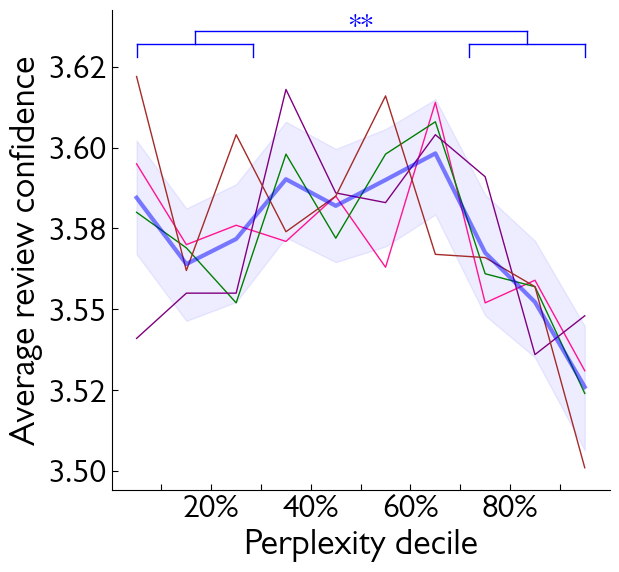

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import bootstrap
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm

file_paths = [
    './openreview_olmo1b_ppl_rating_confidence_rating-disparity.parquet',
    './openreview_olmo7b_ppl_rating_confidence_rating-disparity.parquet',
    './openreview_llama3_ppl_rating_confidence_rating-disparity.parquet',
    './openreview_deepseek_ppl_rating_confidence_rating-disparity.parquet'
]

file_labels = ['OLMo-1B', 'OLMo-7B', 'Llama-3-8B', 'DeepSeek-llm-7B']

color_map = {
    'OLMo-1B': 'deeppink',
    'OLMo-7B': 'green',
    'Llama-3-8B': 'purple',
    'DeepSeek-llm-7B': 'brown'
}

fig, ax = plt.subplots(figsize=(6, 6))

weighted_values = np.zeros(10)
weights = np.zeros(10)

bin_data = {i: [] for i in range(10)}

for file_idx, (file_path, label) in enumerate(zip(file_paths, file_labels)):
    df = pd.read_parquet(file_path)
    df['perplexity_group'] = pd.qcut(df['perplexity'], q=10, labels=False)
    group_stats = df.groupby('perplexity_group').agg({
        'review_avg_confidence': ['mean', 'std'],
        'perplexity': ['min', 'max']
    }).round(3)
    x_values = [(i + 0.5) * 10 for i in range(10)]
    y_values = group_stats['review_avg_confidence']['mean']
    ax.plot(x_values, y_values, linewidth=1, markersize=8, alpha=1, color=color_map[label])
    
    for i in range(10):
        bin_data_i = df[df['perplexity_group'] == i]['review_avg_confidence']
        count = len(bin_data_i)
        
        bin_data[i].extend(bin_data_i.tolist())
        
        weighted_values[i] += y_values[i] * count
        weights[i] += count

weighted_avg = weighted_values / weights

ci_lower = np.zeros(10)
ci_upper = np.zeros(10)

for i in range(10):
    if len(bin_data[i]) > 1:
        try:
            boot_result = bootstrap(
                (np.array(bin_data[i]),), 
                np.mean, 
                confidence_level=0.95,
                random_state=42,
                n_resamples=1000
            )
            ci_lower[i] = boot_result.confidence_interval.low
            ci_upper[i] = boot_result.confidence_interval.high
        except Exception as e:
            print(f"无法计算区间 {i} 的bootstrap CI: {e}")
            std_dev = np.std(bin_data[i])
            ci_lower[i] = weighted_avg[i] - 1.96 * std_dev / np.sqrt(len(bin_data[i]))
            ci_upper[i] = weighted_avg[i] + 1.96 * std_dev / np.sqrt(len(bin_data[i]))
    else:
        ci_lower[i] = weighted_avg[i]
        ci_upper[i] = weighted_avg[i]

ax.plot(x_values, weighted_avg, linewidth=3, color='blue', alpha=0.5)

ax.fill_between(x_values, ci_lower, ci_upper, color='blue', alpha=0.07)

left_bracket_width = 23.33
right_bracket_width = 23.33
bracket_height = 0.004
top_bracket_height = 0.004
vertical_gap = 0

y_max = max(max(weighted_avg), max(ci_upper))
y_base = y_max + 0.013

x_left_center = 16.665
x_right_center = 83.335

x_left_start = x_left_center - left_bracket_width/2
x_left_end = x_left_center + left_bracket_width/2
x_right_start = x_right_center - right_bracket_width/2
x_right_end = x_right_center + right_bracket_width/2

ax.plot([x_left_start, x_left_start], [y_base, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_left_start, x_left_end], [y_base + bracket_height, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_left_end, x_left_end], [y_base + bracket_height, y_base], color='blue', linewidth=1)

ax.plot([x_right_start, x_right_start], [y_base, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_right_start, x_right_end], [y_base + bracket_height, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_right_end, x_right_end], [y_base + bracket_height, y_base], color='blue', linewidth=1)

y_top_base = y_base + bracket_height + vertical_gap
y_top_top = y_top_base + top_bracket_height

ax.plot([x_left_center, x_left_center], [y_base + bracket_height, y_top_base], color='blue', linewidth=1)
ax.plot([x_right_center, x_right_center], [y_base + bracket_height, y_top_base], color='blue', linewidth=1)

ax.plot([x_left_center, x_left_center], [y_top_base, y_top_top], color='blue', linewidth=1)
ax.plot([x_left_center, x_right_center], [y_top_top, y_top_top], color='blue', linewidth=1)
ax.plot([x_right_center, x_right_center], [y_top_top, y_top_base], color='blue', linewidth=1)

ax.text((x_left_center + x_right_center) / 2, y_top_top - 0.0035, "**", 
        ha='center', va='bottom', fontsize=24, color='blue')

all_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
ax.set_xticks(all_ticks)

ax.set_xticklabels([
    "20%" if i == 20 else
    "40%" if i == 40 else
    "60%" if i == 60 else
    "80%" if i == 80 else
    ""
    for i in all_ticks
])

ax.set_xlim(0, 100)

ax.set_xlabel("Perplexity decile", fontsize=26)
ax.set_ylabel("Average review confidence", fontsize=26)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(axis='both', direction='in', length=4)
ax.tick_params(axis='both', labelsize=24) 
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.subplots_adjust(left=0.12, bottom=0.12, right=0.95, top=0.92)
plt.show()

In [ ]:
# Fig. 2d

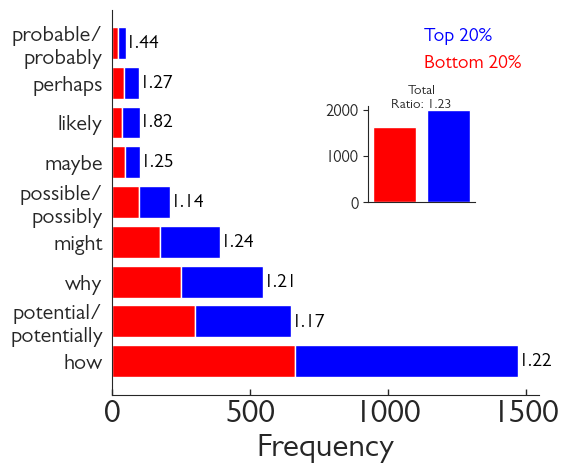

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import matplotlib.font_manager as fm

file_path = './uncertainty_word_avg.csv'
data = pd.read_csv(file_path)

data['Ratio'] = data['frequency_top'] / data['frequency_bottom']

data['total_frequency'] = data['frequency_top'] + data['frequency_bottom']
data = data.sort_values(by='total_frequency', ascending=False)

data['word_display'] = data['word'].str.replace('/', '/\n', regex=False)

total_freq_top = data['frequency_top'].sum()
total_freq_bottom = data['frequency_bottom'].sum()
total_ratio = total_freq_top / total_freq_bottom

plt.figure(figsize=(5.5, 5))

bars1 = plt.barh(data['word_display'], data['frequency_bottom'], color='red', label='PPL_bottom20%')
bars2 = plt.barh(data['word_display'], data['frequency_top'], color='blue', left=data['frequency_bottom'], label='PPL_top20%')

for bar1, bar2, word, ratio in zip(bars1, bars2, data['word_display'], data['Ratio']):
    total_width = bar1.get_width() + bar2.get_width()
    x_pos = total_width + 2
    y_pos = bar1.get_y() + bar1.get_height() / 2
    plt.text(x_pos, y_pos, f'{ratio:.2f}', ha='left', va='center', color='black', fontsize=14)

legend_colors = ['blue', 'red']
legend_labels = ['Top 20%', 'Bottom 20%']
legend_lines = [Line2D([0], [0], color=color, lw=0) for color in legend_colors]
plt.legend(handles=legend_lines,
           labels=legend_labels,
           fontsize=14,
           bbox_to_anchor=(1, 1),
           loc='upper right',
           frameon=False,
           labelcolor=legend_colors,
           prop={'size': 14})

plt.xlabel('Frequency', fontsize=24)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(False)

ax.yaxis.set_tick_params(left=False)

ax.tick_params(axis='x', direction='in', length=4, width=1)

ax.tick_params(axis='y', labelsize=16)

ax.tick_params(axis='x', labelsize=24)

ax_pos = ax.get_position()
small_ax = plt.axes([ax_pos.x0 + ax_pos.width*0.6, ax_pos.y0 + ax_pos.height*0.5, 
                     ax_pos.width*0.25, ax_pos.height*0.25])
small_ax.bar([0, 1], [total_freq_bottom, total_freq_top], color=['red', 'blue'], width=0.8)
small_ax.set_xticks([])
small_ax.tick_params(axis='y', labelsize=12)
small_ax.set_title('Total', fontsize=10, pad=9)
small_ax.text(0.5, 0.98, f'Ratio: {total_ratio:.2f}', ha='center', transform=small_ax.transAxes, 
              fontsize=10)
small_ax.set_yticks([0, 1000, 2000])
small_ax.spines['top'].set_visible(False)
small_ax.spines['right'].set_visible(False)
plt.show()

In [ ]:
# Fig. 2e

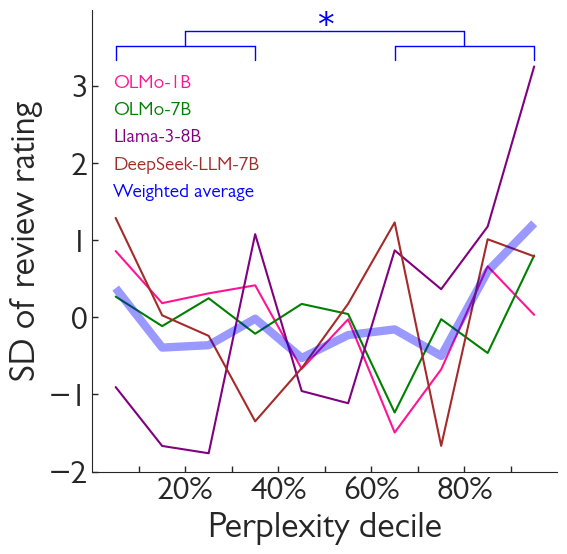

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib
from matplotlib.offsetbox import TextArea, HPacker
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
from scipy.stats import norm

import matplotlib.font_manager as fm

file_paths = [
    './openreview_olmo1b_ppl_rating_confidence_rating-disparity.parquet',
    './openreview_olmo7b_ppl_rating_confidence_rating-disparity.parquet',
    './openreview_llama3_ppl_rating_confidence_rating-disparity.parquet',
    './openreview_deepseek_ppl_rating_confidence_rating-disparity.parquet'
]

file_labels = ['OLMo-1B', 'OLMo-7B', 'Llama-3-8B', 'DeepSeek-LLM-7B']

color_map = {
    'OLMo-1B': 'deeppink',
    'OLMo-7B': 'green',
    'Llama-3-8B': 'purple',
    'DeepSeek-LLM-7B': 'brown'
}

fig, ax = plt.subplots(figsize=(6, 6))
sns.set_style("ticks")

quantiles = np.linspace(0, 1, 11)
midpoints = (quantiles[:-1] + quantiles[1:]) / 2 * 100

all_std_values = []

legend_labels = []
legend_colors = []

model_data = []

for file_path, label in zip(file_paths, file_labels):
    df = pd.read_parquet(file_path, columns=['perplexity', 'review_avg_rating'])

    df['perplexity'] = pd.to_numeric(df['perplexity'], errors='coerce')
    df['review_avg_rating'] = pd.to_numeric(df['review_avg_rating'], errors='coerce')
    df = df.dropna()

    df['perplexity_group'], bins = pd.qcut(df['perplexity'], q=10, retbins=True, labels=False)

    stats = df.groupby('perplexity_group')['review_avg_rating'].agg(std='std', count='count').reset_index()

    all_std_values.extend(stats['std'].values)
    
    model_data.append({
        'label': label,
        'stats': stats[['perplexity_group', 'std', 'count']].values
    })

    color = color_map.get(label, "black")

    legend_labels.append(label)
    legend_colors.append(color)

mean_std = np.mean(all_std_values)
std_dev_std = np.std(all_std_values)

for model in model_data:
    label = model['label']
    stats = model['stats']
    
    perplexity_groups = stats[:, 0].astype(int)
    std_values = stats[:, 1]
    
    normalized_std = (std_values - mean_std) / std_dev_std
    
    color = color_map.get(label, "black")
    ax.plot(midpoints, normalized_std, linestyle='-', label=label, alpha=1, color=color)

weighted_std_sum = np.zeros(10)
total_counts = np.zeros(10)

for model in model_data:
    stats = model['stats']
    for row in stats:
        bin_idx = int(row[0])
        std_val = row[1]
        count = row[2]
        weighted_std_sum[bin_idx] += std_val * count
        total_counts[bin_idx] += count

weighted_std = np.divide(weighted_std_sum, total_counts, where=total_counts > 0)

normalized_weighted_std = (weighted_std - mean_std) / std_dev_std

n_bootstraps = 1000
bootstrap_samples = np.zeros((n_bootstraps, 10))

for i in range(n_bootstraps):
    sampled_models = np.random.choice(len(model_data), len(model_data), replace=True)
    
    boot_weighted_sum = np.zeros(10)
    boot_total_counts = np.zeros(10)
    
    for model_idx in sampled_models:
        stats = model_data[model_idx]['stats']
        for row in stats:
            bin_idx = int(row[0])
            std_val = row[1]
            count = row[2]
            boot_weighted_sum[bin_idx] += std_val * count
            boot_total_counts[bin_idx] += count
    
    with np.errstate(divide='ignore', invalid='ignore'):
        boot_weighted_avg = np.divide(boot_weighted_sum, boot_total_counts, where=boot_total_counts > 0)
        boot_weighted_avg = np.nan_to_num(boot_weighted_avg)
    
    bootstrap_samples[i] = (boot_weighted_avg - mean_std) / std_dev_std

ci_lower = np.percentile(bootstrap_samples, 2.5, axis=0)
ci_upper = np.percentile(bootstrap_samples, 97.5, axis=0)

ax.plot(midpoints, normalized_weighted_std, linestyle='-', color='blue', linewidth=6, alpha=0.4, label='Weighted Avg', solid_capstyle='butt')

left_bracket_width = 30
right_bracket_width = 30
bracket_height = 0.18
top_bracket_height = 0.2
vertical_gap = 0

y_max = max(max(normalized_weighted_std), max(ci_upper))
y_base = y_max + 0.7

x_left_center = 20
x_right_center = 80

x_left_start = x_left_center - left_bracket_width/2
x_left_end = x_left_center + left_bracket_width/2
x_right_start = x_right_center - right_bracket_width/2
x_right_end = x_right_center + right_bracket_width/2

ax.plot([x_left_start, x_left_start], [y_base, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_left_start, x_left_end], [y_base + bracket_height, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_left_end, x_left_end], [y_base + bracket_height, y_base], color='blue', linewidth=1)

ax.plot([x_right_start, x_right_start], [y_base, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_right_start, x_right_end], [y_base + bracket_height, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_right_end, x_right_end], [y_base + bracket_height, y_base], color='blue', linewidth=1)

y_top_base = y_base + bracket_height + vertical_gap
y_top_top = y_top_base + top_bracket_height

ax.plot([x_left_center, x_left_center], [y_base + bracket_height, y_top_base], color='blue', linewidth=1)
ax.plot([x_right_center, x_right_center], [y_base + bracket_height, y_top_base], color='blue', linewidth=1)

ax.plot([x_left_center, x_left_center], [y_top_base, y_top_top], color='blue', linewidth=1)
ax.plot([x_left_center, x_right_center], [y_top_top, y_top_top], color='blue', linewidth=1)
ax.plot([x_right_center, x_right_center], [y_top_top, y_top_base], color='blue', linewidth=1)

ax.text((x_left_center + x_right_center) / 2, y_top_top - 0.15, "*", 
        ha='center', va='bottom', fontsize=24, color='blue')

ax.set_xlabel('Perplexity decile', fontsize=26)
ax.set_ylabel('SD of review rating', fontsize=26)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='both', direction='in', length=4, width=1)

all_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
ax.set_xticks(all_ticks)

ax.set_xticklabels([
    "20%" if i == 20 else
    "40%" if i == 40 else
    "60%" if i == 60 else
    "80%" if i == 80 else
    ""
    for i in all_ticks
])

ax.set_xlim(0, 100)

ax.set_ylim(bottom=-2)

ax.set_yticks([-2, -1, 0, 1, 2, 3])

ax.set_ylim(bottom=-2)

ax.tick_params(axis='both', labelsize=24)

legend_handles = [Line2D([0], [0], color=color, lw=0) for color in legend_colors]
legend_labels_show = legend_labels.copy()

legend_handles.append(Line2D([0], [0], color='blue', lw=0))
legend_labels_show.append('Weighted average')
legend_colors_all = legend_colors + ['blue']

ax.legend(handles=legend_handles, 
          labels=legend_labels_show, fontsize=14, 
          bbox_to_anchor=(-0.11, 0.9), loc='upper left', 
          frameon=False, labelcolor=legend_colors_all,
          prop={'size': 14})

plt.show()

In [ ]:
# Fig. 2f

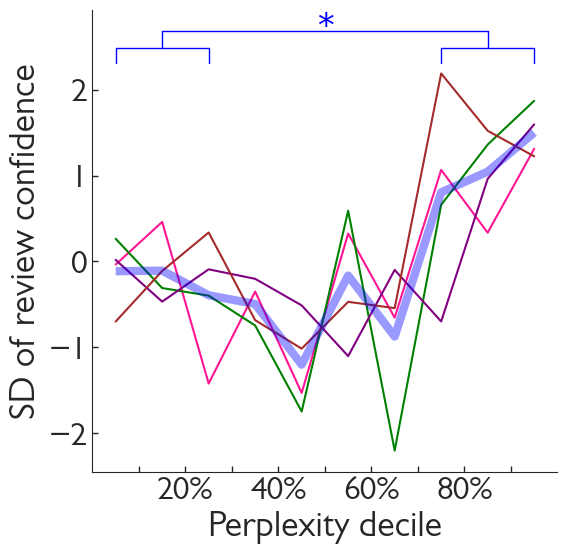

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib
from matplotlib.offsetbox import TextArea, HPacker
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
from scipy.stats import norm

import matplotlib.font_manager as fm

file_paths = [
    './openreview_olmo1b_ppl_rating_confidence_rating-disparity.parquet',
    './openreview_olmo7b_ppl_rating_confidence_rating-disparity.parquet',
    './openreview_llama3_ppl_rating_confidence_rating-disparity.parquet',
    './openreview_deepseek_ppl_rating_confidence_rating-disparity.parquet'
]

file_labels = ['OLMo-1B', 'OLMo-7B', 'Llama-3-8B', 'DeepSeek-llm-7B']

color_map = {
    'OLMo-1B': 'deeppink',
    'OLMo-7B': 'green',
    'Llama-3-8B': 'purple',
    'DeepSeek-llm-7B': 'brown'
}

fig, ax = plt.subplots(figsize=(6, 6))
sns.set_style("ticks")

quantiles = np.linspace(0, 1, 11)
midpoints = (quantiles[:-1] + quantiles[1:]) / 2 * 100

all_std_values = []

legend_labels = []
legend_colors = []

model_data = []

for file_path, label in zip(file_paths, file_labels):
    df = pd.read_parquet(file_path)
    df = df[['perplexity', 'review_avg_confidence']]

    df['perplexity'] = pd.to_numeric(df['perplexity'], errors='coerce')
    df['review_avg_confidence'] = pd.to_numeric(df['review_avg_confidence'], errors='coerce')
    df = df.dropna()

    df['perplexity_group'], bins = pd.qcut(df['perplexity'], q=10, retbins=True, labels=False)

    stats = df.groupby('perplexity_group')['review_avg_confidence'].agg(std='std', count='count').reset_index()

    all_std_values.extend(stats['std'].values)
    
    model_data.append({
        'label': label,
        'stats': stats[['perplexity_group', 'std', 'count']].values
    })

    color = color_map.get(label, "black")

    legend_labels.append(label)
    legend_colors.append(color)

mean_std = np.mean(all_std_values)
std_dev_std = np.std(all_std_values)

for model in model_data:
    label = model['label']
    stats = model['stats']
    
    perplexity_groups = stats[:, 0].astype(int)
    std_values = stats[:, 1]
    
    normalized_std = (std_values - mean_std) / std_dev_std
    
    color = color_map.get(label, "black")
    ax.plot(midpoints, normalized_std, linestyle='-', label=label, alpha=1, color=color)

weighted_std_sum = np.zeros(10)
total_counts = np.zeros(10)

for model in model_data:
    stats = model['stats']
    for row in stats:
        bin_idx = int(row[0])
        std_val = row[1]
        count = row[2]
        weighted_std_sum[bin_idx] += std_val * count
        total_counts[bin_idx] += count

weighted_std = np.divide(weighted_std_sum, total_counts, where=total_counts > 0)

normalized_weighted_std = (weighted_std - mean_std) / std_dev_std

n_bootstraps = 1000
bootstrap_samples = np.zeros((n_bootstraps, 10))

for i in range(n_bootstraps):
    sampled_models = np.random.choice(len(model_data), len(model_data), replace=True)
    
    boot_weighted_sum = np.zeros(10)
    boot_total_counts = np.zeros(10)
    
    for model_idx in sampled_models:
        stats = model_data[model_idx]['stats']
        for row in stats:
            bin_idx = int(row[0])
            std_val = row[1]
            count = row[2]
            boot_weighted_sum[bin_idx] += std_val * count
            boot_total_counts[bin_idx] += count
    
    with np.errstate(divide='ignore', invalid='ignore'):
        boot_weighted_avg = np.divide(boot_weighted_sum, boot_total_counts, where=boot_total_counts > 0)
        boot_weighted_avg = np.nan_to_num(boot_weighted_avg)
    
    bootstrap_samples[i] = (boot_weighted_avg - mean_std) / std_dev_std

ci_lower = np.percentile(bootstrap_samples, 2.5, axis=0)
ci_upper = np.percentile(bootstrap_samples, 97.5, axis=0)

ax.plot(midpoints, normalized_weighted_std, linestyle='-', color='blue', linewidth=6, alpha=0.4, label='Weighted Avg', solid_capstyle='butt')

left_bracket_width = 20
right_bracket_width = 20
bracket_height = 0.18
top_bracket_height = 0.2
vertical_gap = 0

y_max = max(max(normalized_weighted_std), max(ci_upper))
y_base = y_max + 0.5

x_left_center = 15
x_right_center = 85

x_left_start = x_left_center - left_bracket_width/2
x_left_end = x_left_center + left_bracket_width/2
x_right_start = x_right_center - right_bracket_width/2
x_right_end = x_right_center + right_bracket_width/2

ax.plot([x_left_start, x_left_start], [y_base, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_left_start, x_left_end], [y_base + bracket_height, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_left_end, x_left_end], [y_base + bracket_height, y_base], color='blue', linewidth=1)

ax.plot([x_right_start, x_right_start], [y_base, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_right_start, x_right_end], [y_base + bracket_height, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_right_end, x_right_end], [y_base + bracket_height, y_base], color='blue', linewidth=1)

y_top_base = y_base + bracket_height + vertical_gap
y_top_top = y_top_base + top_bracket_height

ax.plot([x_left_center, x_left_center], [y_base + bracket_height, y_top_base], color='blue', linewidth=1)
ax.plot([x_right_center, x_right_center], [y_base + bracket_height, y_top_base], color='blue', linewidth=1)

ax.plot([x_left_center, x_left_center], [y_top_base, y_top_top], color='blue', linewidth=1)
ax.plot([x_left_center, x_right_center], [y_top_top, y_top_top], color='blue', linewidth=1)
ax.plot([x_right_center, x_right_center], [y_top_top, y_top_base], color='blue', linewidth=1)

ax.text((x_left_center + x_right_center) / 2, y_top_top - 0.15, "*", 
        ha='center', va='bottom', fontsize=24, color='blue')

ax.set_xlabel('Perplexity decile', fontsize=26)
ax.set_ylabel('SD of review confidence', fontsize=26)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='both', direction='in', length=4, width=1)

all_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
ax.set_xticks(all_ticks)

ax.set_xticklabels([
    "20%" if i == 20 else
    "40%" if i == 40 else
    "60%" if i == 60 else
    "80%" if i == 80 else
    ""
    for i in all_ticks
])

ax.set_xlim(0, 100)

ax.tick_params(axis='both', labelsize=24) 

legend_handles = [Line2D([0], [0], color=color, lw=0) for color in legend_colors]
legend_labels_show = legend_labels.copy()

plt.show()

In [ ]:
# Fig. 2g

/scratch/local/jobs/59349233/ipykernel_1251198/663766464.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby('perplexity_bins')['days_difference'].agg(


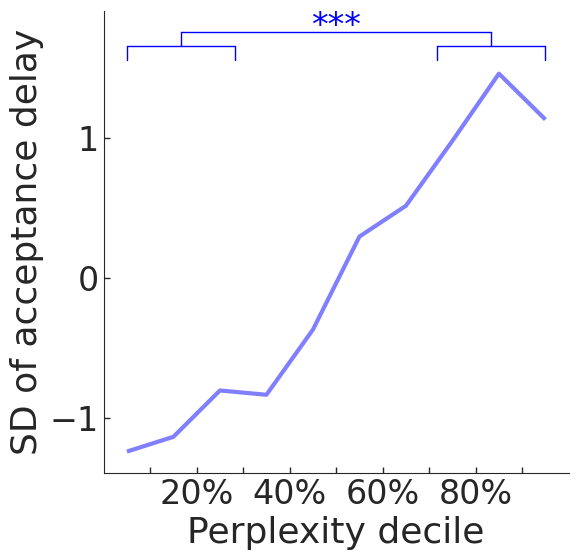

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
from scipy.stats import norm
import matplotlib.font_manager as fm

file_path = "./doi_delay.parquet"
df = pd.read_parquet(file_path, columns=['perplexity', 'days_difference'])

df['perplexity_bins'] = pd.qcut(df['perplexity'], 10, labels=[f'{i*10}-{(i+1)*10}%' for i in range(10)])

stats = df.groupby('perplexity_bins')['days_difference'].agg(
    std='std', 
    count='count',
    mean='mean'
).reset_index()

mean_std = stats['std'].mean()
std_std = stats['std'].std()
if std_std > 0:
    stats['normalized_std'] = (stats['std'] - mean_std) / std_std
else:
    stats['normalized_std'] = np.zeros(len(stats))

fig, ax = plt.subplots(figsize=(6, 6))

perplexity_midpoints = [(i + 0.5) * 10 for i in range(10)]

ax.plot(perplexity_midpoints, stats['normalized_std'], 
        color='blue', linewidth=3, alpha=0.5, linestyle='-', solid_capstyle='butt')

left_bracket_width = 23.33
right_bracket_width = 23.33
bracket_height = 0.1
top_bracket_height = 0.1
vertical_gap = 0

y_max = max(stats['normalized_std'])
y_base = y_max + 0.1

x_left_center = 16.665
x_right_center = 83.335

x_left_start = x_left_center - left_bracket_width/2
x_left_end = x_left_center + left_bracket_width/2
x_right_start = x_right_center - right_bracket_width/2
x_right_end = x_right_center + right_bracket_width/2

ax.plot([x_left_start, x_left_start], [y_base, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_left_start, x_left_end], [y_base + bracket_height, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_left_end, x_left_end], [y_base + bracket_height, y_base], color='blue', linewidth=1)

ax.plot([x_right_start, x_right_start], [y_base, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_right_start, x_right_end], [y_base + bracket_height, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_right_end, x_right_end], [y_base + bracket_height, y_base], color='blue', linewidth=1)

y_top_base = y_base + bracket_height + vertical_gap
y_top_top = y_top_base + top_bracket_height

ax.plot([x_left_center, x_left_center], [y_base + bracket_height, y_top_base], color='blue', linewidth=1)
ax.plot([x_right_center, x_right_center], [y_base + bracket_height, y_top_base], color='blue', linewidth=1)

ax.plot([x_left_center, x_left_center], [y_top_base, y_top_top], color='blue', linewidth=1)
ax.plot([x_left_center, x_right_center], [y_top_top, y_top_top], color='blue', linewidth=1)
ax.plot([x_right_center, x_right_center], [y_top_top, y_top_base], color='blue', linewidth=1)

ax.text((x_left_center + x_right_center) / 2, y_top_top - 0.08, "***", 
        ha='center', va='bottom', fontsize=24, color='blue')

ax.set_xlabel('Perplexity decile', fontsize=26)
ax.set_ylabel('SD of acceptance delay', fontsize=26)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='both', direction='in', length=4, width=1)

all_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
ax.set_xticks(all_ticks)

ax.set_xticklabels([
    "20%" if i == 20 else
    "40%" if i == 40 else
    "60%" if i == 60 else
    "80%" if i == 80 else
    ""
    for i in all_ticks
])

ax.set_xlim(0, 100)

ax.tick_params(axis='both', labelsize=24)

plt.show()

In [ ]:
# Fig. 2h

/scratch/local/jobs/59349233/ipykernel_1240957/1297382631.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby('percentile_group')['impact_factor_2y'].agg([
/scratch/local/jobs/59349233/ipykernel_1240957/1297382631.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby('percentile_group')['impact_factor_2y'].agg([
/scratch/local/jobs/59349233/ipykernel_1240957/1297382631.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futu

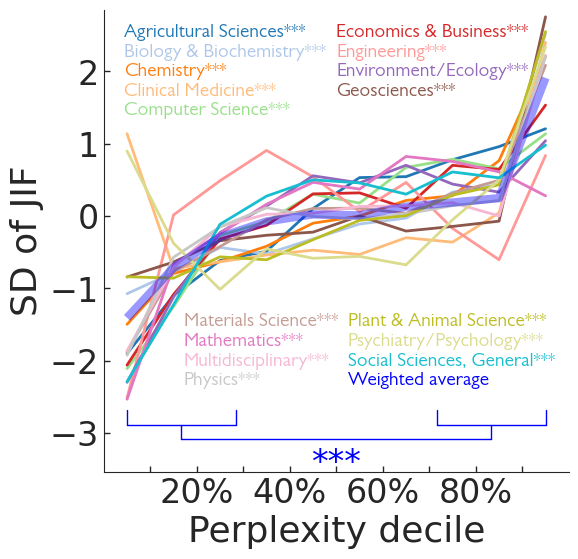

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import matplotlib
import matplotlib.font_manager as fm
from matplotlib.lines import Line2D

data_dir = "./data_field/"
file_paths = glob.glob(os.path.join(data_dir, "*_perplexity.parquet"))

cmap = matplotlib.colormaps.get_cmap("tab20")
colors = [cmap(i / len(file_paths)) for i in range(len(file_paths))]

weighted_sums = np.zeros(10)
total_counts = np.zeros(10)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 6))
sns.set_style("ticks")

label_mapping = {
    'agricultural_science': 'Agricultural Sciences***',
    'biology_biochemistry': 'Biology & Biochemistry***',
    'chemistry': 'Chemistry***',
    'clinical_medicine': 'Clinical Medicine***',
    'computer_science': 'Computer Science***',
    'economics_business': 'Economics & Business***',
    'engineering': 'Engineering***',
    'environment_ecology': 'Environment/Ecology***',
    'geosciences': 'Geosciences***',
    'materials_science': 'Materials Science***',
    'mathematics': 'Mathematics***',
    'multidisciplinary': 'Multidisciplinary***',
    'physics': 'Physics***',
    'plant_animal_science': 'Plant & Animal Science***',
    'psychiatry_psychology': 'Psychiatry/Psychology***',
    'social_sciences_general': 'Social Sciences, General***'
}

legend_labels = []
legend_colors = []
all_y_values = []

for idx, file_path in enumerate(sorted(file_paths)):
    df = pd.read_parquet(file_path)
    
    group_name = os.path.basename(file_path).replace("_perplexity.parquet", "")
    display_name = label_mapping.get(group_name, group_name)
    legend_labels.append(display_name)
    legend_colors.append(colors[idx])
    
    df['percentile_group'] = pd.qcut(df['perplexity'], q=10, labels=range(10))
    stats = df.groupby('percentile_group')['impact_factor_2y'].agg([
        ('mean', 'mean'),
        ('std', 'std'),
        ('count', 'count')
    ]).round(3)
    
    std_mean = stats['std'].mean()
    std_std = stats['std'].std()
    stats['std_normalized'] = ((stats['std'] - std_mean) / std_std).round(3)
    x_values = [(i + 0.5) * 10 for i in range(10)]
    
    weighted_sums += stats['std_normalized'] * stats['count']
    total_counts += stats['count']
    
    all_y_values.extend(stats['std_normalized'].values)
    
    ax1.plot(x_values, stats['std_normalized'], color=colors[idx], linestyle='-', linewidth=2, alpha=1, label=display_name)

weighted_mean = weighted_sums / total_counts
all_y_values.extend(weighted_mean)

ax1.plot(x_values, weighted_mean, color='blue', linestyle='-', linewidth=6, alpha=0.4, label='Weighted average', solid_capstyle='butt')

y_min_bottom = min(all_y_values)
y_base_lower = y_min_bottom - 0.15

lower_left_bracket_width = 23.33
lower_right_bracket_width = 23.33
lower_bracket_height = 0.2
lower_top_bracket_height = 0.2
lower_vertical_gap = 0

x_left_center = 16.665
x_right_center = 83.335

x_left_start_lower = x_left_center - lower_left_bracket_width/2
x_left_end_lower = x_left_center + lower_left_bracket_width/2
x_right_start_lower = x_right_center - lower_right_bracket_width/2
x_right_end_lower = x_right_center + lower_right_bracket_width/2

ax1.plot([x_left_start_lower, x_left_start_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')
ax1.plot([x_left_start_lower, x_left_end_lower], [y_base_lower - lower_bracket_height, y_base_lower - lower_bracket_height], linewidth=1, color='blue')
ax1.plot([x_left_end_lower, x_left_end_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')

ax1.plot([x_right_start_lower, x_right_start_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')
ax1.plot([x_right_start_lower, x_right_end_lower], [y_base_lower - lower_bracket_height, y_base_lower - lower_bracket_height], linewidth=1, color='blue')
ax1.plot([x_right_end_lower, x_right_end_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')

y_top_base_lower = y_base_lower - lower_bracket_height - lower_vertical_gap
y_top_top_lower = y_top_base_lower - lower_top_bracket_height

ax1.plot([x_left_center, x_left_center], [y_base_lower - lower_bracket_height, y_top_base_lower], linewidth=1, color='blue')
ax1.plot([x_right_center, x_right_center], [y_base_lower - lower_bracket_height, y_top_base_lower], linewidth=1, color='blue')

ax1.plot([x_left_center, x_left_center], [y_top_base_lower, y_top_top_lower], linewidth=1, color='blue')
ax1.plot([x_left_center, x_right_center], [y_top_top_lower, y_top_top_lower], linewidth=1, color='blue')
ax1.plot([x_right_center, x_right_center], [y_top_top_lower, y_top_base_lower], linewidth=1, color='blue')

ax1.text((x_left_center + x_right_center) / 2, y_top_top_lower - 0.1, "***", 
        ha='center', va='top', fontsize=24, color='blue')

ax1.set_xlabel('Perplexity decile', fontsize=26)
ax1.set_ylabel('SD of JIF', fontsize=26)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(axis='both', which='both', direction='in', length=4, width=1)

x_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([
    "20%" if i == 20 else
    "40%" if i == 40 else
    "60%" if i == 60 else
    "80%" if i == 80 else
    ""
    for i in x_ticks
])

ax1.set_xlim(0, 100)

y_plot_min = min(y_top_top_lower - 0.1, min(all_y_values) - 1)
y_plot_max = max(all_y_values) + 0.1
ax1.set_ylim(y_plot_min, y_plot_max)

ax1.tick_params(axis='both', labelsize=24)

y_range = y_plot_max - y_plot_min
y_ticks = np.linspace(int(y_plot_min), int(y_plot_max), max(3, int(y_range)))
ax1.set_yticks(y_ticks)

ax1.grid(False)

legend_labels.append('Weighted average')
legend_colors.append('blue')

legend1_x = -0.09
legend1_y = 1.03

legend2_x = 1.0
legend2_y = -0.5

first_legend_count = 9
legend_labels_first = legend_labels[:first_legend_count]
legend_colors_first = legend_colors[:first_legend_count]
legend_labels_second = legend_labels[first_legend_count:]
legend_colors_second = legend_colors[first_legend_count:]

legend_handles_first = [Line2D([0], [0], color=color, lw=0) for color in legend_colors_first]
legend1 = ax1.legend(handles=legend_handles_first, 
                    labels=legend_labels_first, fontsize=14,
                    bbox_to_anchor=(legend1_x, 1), loc='upper left', 
                    frameon=False, labelcolor=legend_colors_first,
                    prop={'size': 14}, 
                    ncol=2, columnspacing=-2, 
                    handletextpad=0.5,
                    borderpad=0.2,
                    labelspacing=0.1)

ax1.add_artist(legend1)

legend_handles_second = [Line2D([0], [0], color=color, lw=0) for color in legend_colors_second]
legend2 = ax1.legend(handles=legend_handles_second, 
                    labels=legend_labels_second, fontsize=14,
                    bbox_to_anchor=(legend2_x, 0.15), loc='lower right', 
                    frameon=False, labelcolor=legend_colors_second,
                    prop={'size': 14}, 
                    ncol=2, columnspacing=-2, 
                    handletextpad=0.5,
                    borderpad=0.2,
                    labelspacing=0.1)

plt.show()

In [ ]:
# Fig. 2i

/scratch/local/jobs/59349233/ipykernel_1240957/1208827953.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby('percentile_group')['impact_factor_2y'].agg([
/scratch/local/jobs/59349233/ipykernel_1240957/1208827953.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby('percentile_group')['impact_factor_2y'].agg([
/scratch/local/jobs/59349233/ipykernel_1240957/1208827953.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futu

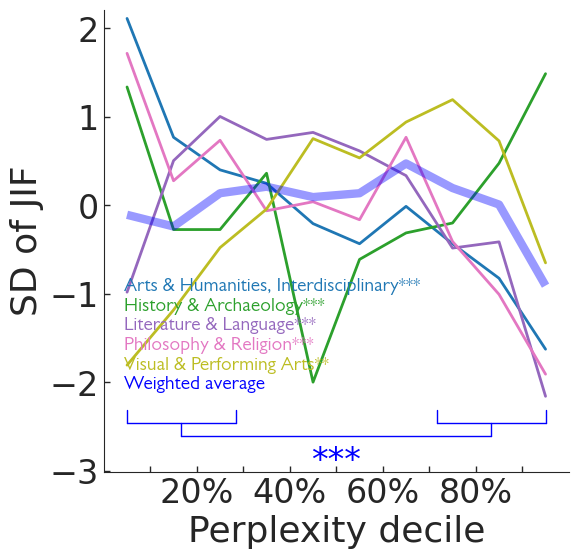

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import matplotlib
import matplotlib.font_manager as fm
from matplotlib.lines import Line2D

data_dir = "./data_field/"
file_paths = glob.glob(os.path.join(data_dir, "*_perplexity1.parquet"))

cmap = matplotlib.colormaps.get_cmap("tab20")
colors = [cmap(i / len(file_paths)) for i in range(len(file_paths))]

weighted_sums = np.zeros(10)
total_counts = np.zeros(10)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 6))
sns.set_style("ticks")

label_mapping = {
    'arts_humanities_interdisciplinary': 'Arts & Humanities, Interdisciplinary***',
    'history_archaeology': 'History & Archaeology***',
    'literature_language': 'Literature & Language***',
    'philosophy_religion': 'Philosophy & Religion***',
    'visual_performing_arts': 'Visual & Performing Arts**'
}

legend_labels = []
legend_colors = []
all_y_values = []

for idx, file_path in enumerate(sorted(file_paths)):
    df = pd.read_parquet(file_path)
    
    group_name = os.path.basename(file_path).replace("_perplexity1.parquet", "")
    display_name = label_mapping.get(group_name, group_name)
    legend_labels.append(display_name)
    legend_colors.append(colors[idx])
    
    df['percentile_group'] = pd.qcut(df['perplexity'], q=10, labels=range(10))
    stats = df.groupby('percentile_group')['impact_factor_2y'].agg([
        ('mean', 'mean'),
        ('std', 'std'),
        ('count', 'count')
    ]).round(3)
    
    std_mean = stats['std'].mean()
    std_std = stats['std'].std()
    stats['std_normalized'] = ((stats['std'] - std_mean) / std_std).round(3)
    x_values = [(i + 0.5) * 10 for i in range(10)]
    
    weighted_sums += stats['std_normalized'] * stats['count']
    total_counts += stats['count']
    
    all_y_values.extend(stats['std_normalized'].values)
    
    ax1.plot(x_values, stats['std_normalized'], color=colors[idx], linestyle='-', linewidth=2, alpha=1, label=display_name)

weighted_mean = weighted_sums / total_counts
all_y_values.extend(weighted_mean)

ax1.plot(x_values, weighted_mean, color='blue', linestyle='-', linewidth=6, alpha=0.4, label='Weighted average', solid_capstyle='butt')

y_min_bottom = min(all_y_values)
y_base_lower = y_min_bottom - 0.15

lower_left_bracket_width = 23.33
lower_right_bracket_width = 23.33
lower_bracket_height = 0.15
lower_top_bracket_height = 0.15
lower_vertical_gap = 0

x_left_center = 16.665
x_right_center = 83.335

x_left_start_lower = x_left_center - lower_left_bracket_width/2
x_left_end_lower = x_left_center + lower_left_bracket_width/2
x_right_start_lower = x_right_center - lower_right_bracket_width/2
x_right_end_lower = x_right_center + lower_right_bracket_width/2

ax1.plot([x_left_start_lower, x_left_start_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')
ax1.plot([x_left_start_lower, x_left_end_lower], [y_base_lower - lower_bracket_height, y_base_lower - lower_bracket_height], linewidth=1, color='blue')
ax1.plot([x_left_end_lower, x_left_end_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')

ax1.plot([x_right_start_lower, x_right_start_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')
ax1.plot([x_right_start_lower, x_right_end_lower], [y_base_lower - lower_bracket_height, y_base_lower - lower_bracket_height], linewidth=1, color='blue')
ax1.plot([x_right_end_lower, x_right_end_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')

y_top_base_lower = y_base_lower - lower_bracket_height - lower_vertical_gap
y_top_top_lower = y_top_base_lower - lower_top_bracket_height

ax1.plot([x_left_center, x_left_center], [y_base_lower - lower_bracket_height, y_top_base_lower], linewidth=1, color='blue')
ax1.plot([x_right_center, x_right_center], [y_base_lower - lower_bracket_height, y_top_base_lower], linewidth=1, color='blue')

ax1.plot([x_left_center, x_left_center], [y_top_base_lower, y_top_top_lower], linewidth=1, color='blue')
ax1.plot([x_left_center, x_right_center], [y_top_top_lower, y_top_top_lower], linewidth=1, color='blue')
ax1.plot([x_right_center, x_right_center], [y_top_top_lower, y_top_base_lower], linewidth=1, color='blue')

ax1.text((x_left_center + x_right_center) / 2, y_top_top_lower - 0.1, "***", 
        ha='center', va='top', fontsize=24, color='blue')

ax1.set_xlabel('Perplexity decile', fontsize=26)
ax1.set_ylabel('SD of JIF', fontsize=26)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(axis='both', which='both', direction='in', length=4, width=1)

x_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([
    "20%" if i == 20 else
    "40%" if i == 40 else
    "60%" if i == 60 else
    "80%" if i == 80 else
    ""
    for i in x_ticks
])

ax1.set_xlim(0, 100)

y_plot_min = min(y_top_top_lower - 0.1, min(all_y_values) - 0.85)
y_plot_max = max(all_y_values) + 0.1
ax1.set_ylim(y_plot_min, y_plot_max)

ax1.tick_params(axis='both', labelsize=24)

y_range = y_plot_max - y_plot_min
y_ticks = np.arange(int(np.ceil(y_plot_min)), int(np.floor(y_plot_max)) + 1, 1)
ax1.set_yticks(y_ticks)

ax1.grid(False)

legend_labels.append('Weighted average')
legend_colors.append('blue')

legend1_x = -0.09
legend1_handletextpad = 0.5
legend1_borderpad = 0.2
legend1_labelspacing = 0.1

legend_handles = [Line2D([0], [0], color=color, lw=0) for color in legend_colors]
legend1 = ax1.legend(handles=legend_handles, 
                    labels=legend_labels, fontsize=14,
                    bbox_to_anchor=(legend1_x, 0.45), loc='upper left', 
                    frameon=False, labelcolor=legend_colors,
                    prop={'size': 14}, 
                    ncol=1, columnspacing=-1, 
                    handletextpad=legend1_handletextpad,
                    borderpad=legend1_borderpad,
                    labelspacing=legend1_labelspacing)

plt.show()

In [9]:
# Fig. 3a

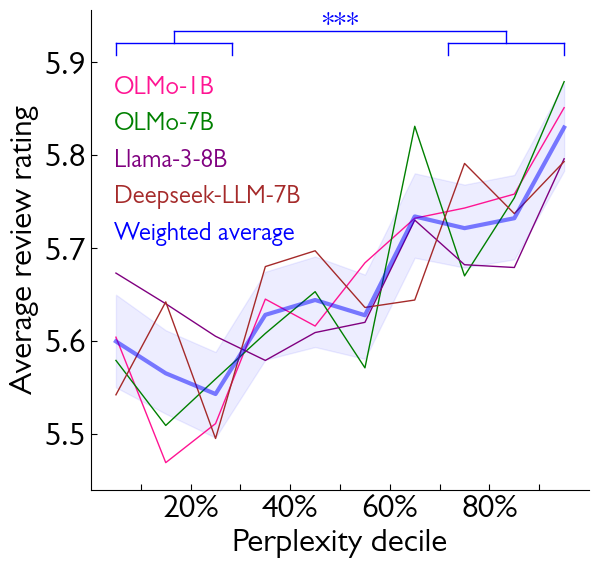

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import matplotlib.font_manager as fm

file_paths = [
    './openreview_olmo1b_ppl_rating_confidence_rating-disparity.parquet',
    './openreview_olmo7b_ppl_rating_confidence_rating-disparity.parquet',
    './openreview_llama3_ppl_rating_confidence_rating-disparity.parquet',
    './openreview_deepseek_ppl_rating_confidence_rating-disparity.parquet'
]
file_labels = ['OLMo-1B', 'OLMo-7B', 'Llama-3-8B', 'Deepseek-LLM-7B']
color_map = {
    'OLMo-1B': 'deeppink',
    'OLMo-7B': 'green',
    'Llama-3-8B': 'purple',
    'Deepseek-LLM-7B': 'brown'
}

fig, ax = plt.subplots(figsize=(6, 6))

all_data = []

for file_idx, (file_path, label) in enumerate(zip(file_paths, file_labels)):
    df = pd.read_parquet(file_path)
    df['model'] = label
    df['perplexity_group'] = pd.qcut(df['perplexity'], q=10, labels=False)
    all_data.append(df)
    group_stats = df.groupby('perplexity_group').agg({
        'review_avg_rating': ['mean', 'std'],
        'perplexity': ['min', 'max']
    }).round(3)
    
    x_values = [(i + 0.5) * 10 for i in range(10)]  # 每个区间的中心点百分比
    y_values = group_stats['review_avg_rating']['mean']
    
    ax.plot(x_values, y_values, linewidth=1, markersize=8, alpha=1, color=color_map[label])

combined_data = pd.concat(all_data, ignore_index=True)

x_values = [(i + 0.5) * 10 for i in range(10)]

weighted_avg = np.zeros(10)
for i in range(10):
    bin_data = combined_data[combined_data['perplexity_group'] == i]
    if not bin_data.empty:
        weighted_avg[i] = bin_data['review_avg_rating'].mean()

n_bootstraps = 1000
bootstrap_results = np.zeros((n_bootstraps, 10))

for b in range(n_bootstraps):
    for i in range(10):
        bin_data = combined_data[combined_data['perplexity_group'] == i]
        if len(bin_data) > 0:
            bootstrap_sample = bin_data.sample(n=len(bin_data), replace=True)
            bootstrap_results[b, i] = bootstrap_sample['review_avg_rating'].mean()
        else:
            bootstrap_results[b, i] = np.nan

ci_lower = np.percentile(bootstrap_results, 2.5, axis=0)
ci_upper = np.percentile(bootstrap_results, 97.5, axis=0)

ax.plot(x_values, weighted_avg, linewidth=3, color='blue', alpha=0.5)

ax.fill_between(x_values, ci_lower, ci_upper, color='blue', alpha=0.07)

# 可调参数
left_bracket_width = 23.33
right_bracket_width = 23.33
bracket_height = 0.013
top_bracket_height = 0.013
vertical_gap = 0

y_max = max(max(weighted_avg), max(ci_upper))
y_base = y_max + 0.03

# 定义左右方框的位置
x_left_center = 16.665
x_right_center = 83.335

x_left_start = x_left_center - left_bracket_width/2
x_left_end = x_left_center + left_bracket_width/2
x_right_start = x_right_center - right_bracket_width/2
x_right_end = x_right_center + right_bracket_width/2

ax.plot([x_left_start, x_left_start], [y_base, y_base + bracket_height], color='blue', linewidth=1)  # 左边
ax.plot([x_left_start, x_left_end], [y_base + bracket_height, y_base + bracket_height], color='blue', linewidth=1)  # 顶边
ax.plot([x_left_end, x_left_end], [y_base + bracket_height, y_base], color='blue', linewidth=1)    # 右边

ax.plot([x_right_start, x_right_start], [y_base, y_base + bracket_height], color='blue', linewidth=1)  # 左边
ax.plot([x_right_start, x_right_end], [y_base + bracket_height, y_base + bracket_height], color='blue', linewidth=1)  # 顶边
ax.plot([x_right_end, x_right_end], [y_base + bracket_height, y_base], color='blue', linewidth=1)    # 右边

y_top_base = y_base + bracket_height + vertical_gap
y_top_top = y_top_base + top_bracket_height

ax.plot([x_left_center, x_left_center], [y_base + bracket_height, y_top_base], color='blue', linewidth=1)
ax.plot([x_right_center, x_right_center], [y_base + bracket_height, y_top_base], color='blue', linewidth=1)

ax.plot([x_left_center, x_left_center], [y_top_base, y_top_top], color='blue', linewidth=1)    # 左边
ax.plot([x_left_center, x_right_center], [y_top_top, y_top_top], color='blue', linewidth=1)    # 顶边
ax.plot([x_right_center, x_right_center], [y_top_top, y_top_base], color='blue', linewidth=1)  # 右边

ax.text((x_left_center + x_right_center) / 2, y_top_top - 0.01, "***", 
        ha='center', va='bottom', fontsize=24, color='blue')

all_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
ax.set_xticks(all_ticks)

ax.set_xticklabels([
    "20%" if i == 20 else
    "40%" if i == 40 else
    "60%" if i == 60 else
    "80%" if i == 80 else
    ""
    for i in all_ticks
])

ax.set_xlim(0, 100)
ax.set_ylim(bottom=5.44)

ax.set_xlabel("Perplexity decile", fontsize=24)
ax.set_ylabel("Average review rating", fontsize=24)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_labels = file_labels + ['Weighted average']
legend_colors = [color_map[label] for label in file_labels] + ['blue']

ax.legend(
    handles=[Line2D([0], [0], color=color, lw=0) for color in legend_colors],  # 设置 lw=0 使线条不可见
    labels=legend_labels,
    fontsize=18,
    bbox_to_anchor=(-0.14, 0.91),
    loc='upper left',
    frameon=False,
    ncol=1,  # 设置为单列
    labelcolor=legend_colors
)

ax.tick_params(axis='both', direction='in', length=4)
ax.tick_params(axis='both', labelsize=24) 

plt.subplots_adjust(left=0.12, bottom=0.12, right=0.95, top=0.92)
plt.show()

In [1]:
# Fig. 3b

Successfully loaded font: Gill Sans


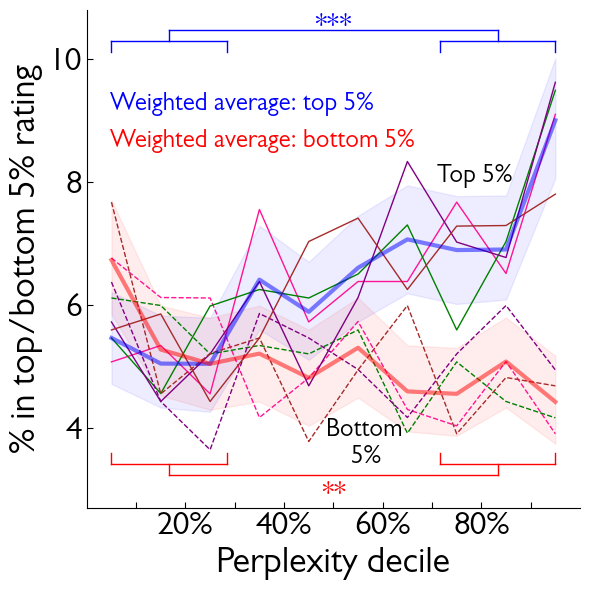

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import matplotlib.font_manager as fm

file_paths = [
    './openreview_olmo1b_ppl_rating_confidence_rating-disparity.parquet',
    './openreview_olmo7b_ppl_rating_confidence_rating-disparity.parquet',
    './openreview_llama3_ppl_rating_confidence_rating-disparity.parquet',
    './openreview_deepseek_ppl_rating_confidence_rating-disparity.parquet'
]

file_labels = ['OLMo-1B', 'OLMo-7B', 'Llama-3-8B', 'DeepSeek-llm-7B']

color_map = {
    'OLMo-1B': 'deeppink',
    'OLMo-7B': 'green',
    'Llama-3-8B': 'purple',
    'DeepSeek-llm-7B': 'brown'
}

plt.figure(figsize=(6, 6))
ax = plt.gca()
plt.xlabel("Perplexity decile", fontsize=26)
plt.ylabel("% in top/bottom 5% rating", fontsize=26)
plt.grid(False)

all_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
ax.set_xticks(all_ticks)

ax.set_xticklabels([
    "20%" if i == 20 else
    "40%" if i == 40 else
    "60%" if i == 60 else
    "80%" if i == 80 else
    ""
    for i in all_ticks
])

ax.set_xlim(0, 100)
ax.set_ylim(2.5, 10.5)

x_values = np.arange(5, 100, 10)

all_data = []

for file_path, label in zip(file_paths, file_labels):
    df = pd.read_parquet(file_path)
    
    df['perplexity'] = pd.to_numeric(df['perplexity'], errors='coerce')
    df['review_avg_rating'] = pd.to_numeric(df['review_avg_rating'], errors='coerce')
    
    df = df.dropna()
    
    df['model'] = label
    
    df['perplexity_bins'] = pd.qcut(df['perplexity'], 10, labels=False)
    
    all_data.append(df)
    
    threshold_confidence_top = df['review_avg_rating'].quantile(0.95)
    threshold_confidence_bottom = df['review_avg_rating'].quantile(0.05)
    
    percentages_top = np.zeros(10)  
    percentages_bottom = np.zeros(10)  
    
    for bin_idx in range(10):
        subset = df[df['perplexity_bins'] == bin_idx]
        n = len(subset)
        
        if n > 0:
            percentage_top = (subset['review_avg_rating'] >= threshold_confidence_top).sum() / n * 100
            percentage_bottom = (subset['review_avg_rating'] <= threshold_confidence_bottom).sum() / n * 100
            
            percentages_top[bin_idx] = percentage_top
            percentages_bottom[bin_idx] = percentage_bottom

    plt.plot(x_values, percentages_top, linewidth=1, linestyle='-', alpha=1, 
             color=color_map[label])
    plt.plot(x_values, percentages_bottom, linewidth=1, linestyle='--', alpha=1, 
             color=color_map[label])

combined_data = pd.concat(all_data, ignore_index=True)

threshold_all_top = combined_data['review_avg_rating'].quantile(0.95)
threshold_all_bottom = combined_data['review_avg_rating'].quantile(0.05)

weighted_top_avg = np.zeros(10)
weighted_bottom_avg = np.zeros(10)

for bin_idx in range(10):
    bin_data = combined_data[combined_data['perplexity_bins'] == bin_idx]
    if len(bin_data) > 0:
        weighted_top_avg[bin_idx] = (bin_data['review_avg_rating'] >= threshold_all_top).sum() / len(bin_data) * 100
        weighted_bottom_avg[bin_idx] = (bin_data['review_avg_rating'] <= threshold_all_bottom).sum() / len(bin_data) * 100

n_bootstraps = 1000
bootstrap_top = np.zeros((n_bootstraps, 10))
bootstrap_bottom = np.zeros((n_bootstraps, 10))

for b in range(n_bootstraps):
    for bin_idx in range(10):
        bin_data = combined_data[combined_data['perplexity_bins'] == bin_idx]
        if len(bin_data) > 0:
            bootstrap_sample = bin_data.sample(n=len(bin_data), replace=True)
            bootstrap_top[b, bin_idx] = (bootstrap_sample['review_avg_rating'] >= threshold_all_top).sum() / len(bootstrap_sample) * 100
            bootstrap_bottom[b, bin_idx] = (bootstrap_sample['review_avg_rating'] <= threshold_all_bottom).sum() / len(bootstrap_sample) * 100
        else:
            bootstrap_top[b, bin_idx] = np.nan
            bootstrap_bottom[b, bin_idx] = np.nan

ci_lower_top = np.percentile(bootstrap_top, 2.5, axis=0)
ci_upper_top = np.percentile(bootstrap_top, 97.5, axis=0)
ci_lower_bottom = np.percentile(bootstrap_bottom, 2.5, axis=0)
ci_upper_bottom = np.percentile(bootstrap_bottom, 97.5, axis=0)

plt.plot(x_values, weighted_top_avg, linewidth=3, linestyle='-', color='blue', label='Weighted Avg', alpha=0.5)
plt.plot(x_values, weighted_bottom_avg, linewidth=3, linestyle='-', color='red', alpha=0.5)

plt.fill_between(x_values, ci_lower_top, ci_upper_top, color='blue', alpha=0.07)
plt.fill_between(x_values, ci_lower_bottom, ci_upper_bottom, color='red', alpha=0.07)

upper_left_bracket_width = 23.33
upper_right_bracket_width = 23.33
upper_bracket_height = 0.18
upper_top_bracket_height = 0.38
upper_vertical_gap = 0

lower_left_bracket_width = 23.33
lower_right_bracket_width = 23.33
lower_bracket_height = 0.18
lower_top_bracket_height = 0.18
lower_vertical_gap = 0

y_max_top = max(max(weighted_top_avg), max(ci_upper_top))
y_base_upper = y_max_top + 0.1

x_left_center = 16.665
x_right_center = 83.335

x_left_start = x_left_center - upper_left_bracket_width/2
x_left_end = x_left_center + upper_left_bracket_width/2
x_right_start = x_right_center - upper_right_bracket_width/2
x_right_end = x_right_center + upper_right_bracket_width/2

ax.plot([x_left_start, x_left_start], [y_base_upper, y_base_upper + upper_bracket_height], linewidth=1, color='blue')
ax.plot([x_left_start, x_left_end], [y_base_upper + upper_bracket_height, y_base_upper + upper_bracket_height], linewidth=1, color='blue')
ax.plot([x_left_end, x_left_end], [y_base_upper + upper_bracket_height, y_base_upper], linewidth=1, color='blue')

ax.plot([x_right_start, x_right_start], [y_base_upper, y_base_upper + upper_bracket_height], linewidth=1, color='blue')
ax.plot([x_right_start, x_right_end], [y_base_upper + upper_bracket_height, y_base_upper + upper_bracket_height], linewidth=1, color='blue')
ax.plot([x_right_end, x_right_end], [y_base_upper + upper_bracket_height, y_base_upper], linewidth=1, color='blue')

y_top_base_upper = y_base_upper + upper_bracket_height + upper_vertical_gap
y_top_top_upper = y_top_base_upper + upper_top_bracket_height - 0.2

ax.plot([x_left_center, x_left_center], [y_base_upper + upper_bracket_height, y_top_base_upper], linewidth=1, color='blue')
ax.plot([x_right_center, x_right_center], [y_base_upper + upper_bracket_height, y_top_base_upper], linewidth=1, color='blue')

ax.plot([x_left_center, x_left_center], [y_top_base_upper, y_top_top_upper], linewidth=1, color='blue')
ax.plot([x_left_center, x_right_center], [y_top_top_upper, y_top_top_upper], linewidth=1, color='blue')
ax.plot([x_right_center, x_right_center], [y_top_top_upper, y_top_base_upper], linewidth=1, color='blue')

ax.text((x_left_center + x_right_center) / 2, y_top_top_upper - 0.2, "***", 
        ha='center', va='bottom', fontsize=24, color='blue')

y_min_bottom = min(min(weighted_bottom_avg), min(ci_lower_bottom))
y_base_lower = y_min_bottom - 0.15

x_left_start_lower = x_left_center - lower_left_bracket_width/2
x_left_end_lower = x_left_center + lower_left_bracket_width/2
x_right_start_lower = x_right_center - lower_right_bracket_width/2
x_right_end_lower = x_right_center + lower_right_bracket_width/2

ax.plot([x_left_start_lower, x_left_start_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='red')
ax.plot([x_left_start_lower, x_left_end_lower], [y_base_lower - lower_bracket_height, y_base_lower - lower_bracket_height], linewidth=1, color='red')
ax.plot([x_left_end_lower, x_left_end_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='red')

ax.plot([x_right_start_lower, x_right_start_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='red')
ax.plot([x_right_start_lower, x_right_end_lower], [y_base_lower - lower_bracket_height, y_base_lower - lower_bracket_height], linewidth=1, color='red')
ax.plot([x_right_end_lower, x_right_end_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='red')

y_top_base_lower = y_base_lower - lower_bracket_height - lower_vertical_gap
y_top_top_lower = y_top_base_lower - lower_top_bracket_height

ax.plot([x_left_center, x_left_center], [y_base_lower - lower_bracket_height, y_top_base_lower], linewidth=1, color='red')
ax.plot([x_right_center, x_right_center], [y_base_lower - lower_bracket_height, y_top_base_lower], linewidth=1, color='red')

ax.plot([x_left_center, x_left_center], [y_top_base_lower, y_top_top_lower], linewidth=1, color='red')
ax.plot([x_left_center, x_right_center], [y_top_top_lower, y_top_top_lower], linewidth=1, color='red')
ax.plot([x_right_center, x_right_center], [y_top_top_lower, y_top_base_lower], linewidth=1, color='red')

ax.text((x_left_center + x_right_center) / 2, y_top_top_lower - 0.1, "**", 
        ha='center', va='top', fontsize=24, color='red')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(
    handles=[
        Line2D([0], [0], color='blue', lw=0),
        Line2D([0], [0], color='red', lw=0)
    ],
    labels=['Weighted average: top 5%', 'Weighted average: bottom 5%'],
    fontsize=18,
    bbox_to_anchor=(-0.14, 0.88),
    loc='upper left',
    frameon=False,
    ncol=1,
    labelcolor=['blue', 'red']
)

plt.text(71, 8, 'Top 5%', fontsize=18, color='black')
plt.text(48.6, 3.42, 'Bottom\n    5%', fontsize=18, color='black')

ax.tick_params(axis='both', direction='in', length=4)
ax.tick_params(axis='both', labelsize=24) 
ax.set_ylim(2.7, 10.8)

plt.tight_layout()
plt.show()

In [4]:
# Fig. 3c

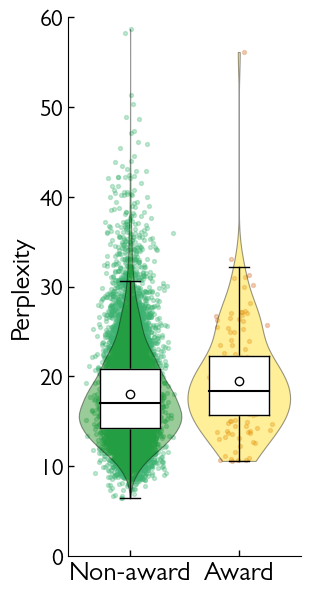

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.font_manager as fm

file_path = "./semantic_scholar_ppl_award_olmo1b.parquet"
df = pd.read_parquet(file_path)

df = df.dropna(subset=['perplexity'])

award_papers = df[df['is_award'] == 1]['perplexity']
non_award_papers = df[df['is_award'] == 0]['perplexity']

data_to_plot = [non_award_papers, award_papers]
labels = ['Non-award', 'Award']

plt.figure(figsize=(3, 7))

plt.rcParams['axes.grid'] = False

positions = [0.5, 0.518]

colors = ['mediumseagreen', 'chocolate']
for i, data in enumerate(data_to_plot):
    x = np.random.normal(positions[i], 0.002, size=len(data))
    plt.scatter(x, data, alpha=0.3, s=8, color=colors[i], zorder=1)

violin_width = 0.017
violin_parts = plt.violinplot(data_to_plot, positions=positions, 
                             showmeans=False, showmedians=False, 
                             showextrema=False, widths=violin_width)

violin_colors = ['green', 'gold']
for i, pc in enumerate(violin_parts['bodies']):
    pc.set_facecolor(violin_colors[i])
    pc.set_edgecolor('black')
    pc.set_alpha(0.4)
    pc.set_linewidth(0.8)

box_width = 0.01
box_color = 'white'
means = []

for i, data in enumerate(data_to_plot):
    pos = positions[i]
    
    q1, median, q3 = np.percentile(data, [25, 50, 75])
    iqr = q3 - q1
    whisker_min = max(np.min(data), q1 - 1.5 * iqr)
    whisker_max = min(np.max(data), q3 + 1.5 * iqr)
    
    means.append(np.mean(data))
    
    plt.plot([pos-box_width/2, pos+box_width/2], [q1, q1], color='black', linewidth=1, zorder=7)
    plt.plot([pos-box_width/2, pos+box_width/2], [q3, q3], color='black', linewidth=1, zorder=7)
    plt.plot([pos-box_width/2, pos-box_width/2], [q1, q3], color='black', linewidth=1, zorder=7)
    plt.plot([pos+box_width/2, pos+box_width/2], [q1, q3], color='black', linewidth=1, zorder=7)
    
    plt.fill_between([pos-box_width/2, pos+box_width/2], [q1, q1], [q3, q3], color=box_color, zorder=5)
    
    plt.plot([pos-box_width/2, pos+box_width/2], [median, median], color='black', linewidth=1.5, zorder=8)
    
    plt.plot([pos, pos], [q1, whisker_min], color='black', linestyle='-', linewidth=1, zorder=4)
    plt.plot([pos, pos], [q3, whisker_max], color='black', linestyle='-', linewidth=1, zorder=4)
    
    whisker_cap = box_width/3
    plt.plot([pos-whisker_cap/2, pos+whisker_cap/2], [whisker_min, whisker_min], color='black', linewidth=1, zorder=4)
    plt.plot([pos-whisker_cap/2, pos+whisker_cap/2], [whisker_max, whisker_max], color='black', linewidth=1, zorder=4)

for i, pos in enumerate(positions):
    plt.plot(pos, means[i], 'o', color='white', markersize=6, markeredgecolor='black', markeredgewidth=1, zorder=9)

plt.xticks(positions, labels, fontsize=19)
plt.ylabel('Perplexity', fontsize=19)

y_max = max([np.max(award_papers), np.max(non_award_papers)])
y_min = min([np.min(award_papers), np.min(non_award_papers)])
y_range = y_max - y_min

ax = plt.gca()

ax.tick_params(axis='both', which='both', direction='in', colors='black', length=4, width=1)

current_yticks = ax.get_yticks()
plt.yticks(fontsize=17)

yticks_positions = ax.get_yticks()
yticks_labels = [str(int(tick)) if tick == int(tick) else str(tick) for tick in yticks_positions]

ax.set_yticks(yticks_positions)
ax.set_yticklabels(yticks_labels, fontsize=17)

for i, tick_val in enumerate(yticks_positions):
    if abs(tick_val - 0) < 1e-10:
        ax.tick_params(axis='y', which='major', direction='in', colors='black', length=0, width=1)
        other_ticks = [t for t in yticks_positions if abs(t - 0) >= 1e-10]
        break

class CustomTick:
    def __init__(self, ax):
        self.ax = ax
    
    def set_tick_params(self):
        self.ax.tick_params(axis='y', which='major', direction='in', colors='black', length=4, width=1)
        
        tick_locs = self.ax.yaxis.get_majorticklocs()
        
        for i, loc in enumerate(tick_locs):
            if abs(loc - 0) < 1e-10:
                tick_lines = self.ax.yaxis.get_majorticklines()
                if i*2 < len(tick_lines):
                    tick_lines[i*2].set_markersize(0)
                    tick_lines[i*2].set_markeredgewidth(0)
                if i*2+1 < len(tick_lines):
                    tick_lines[i*2+1].set_markersize(0)
                    tick_lines[i*2+1].set_markeredgewidth(0)

custom_tick = CustomTick(ax)
custom_tick.set_tick_params()

for spine in ax.spines.values():
    spine.set_color('black')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.ylim(0, 60)

plt.show()

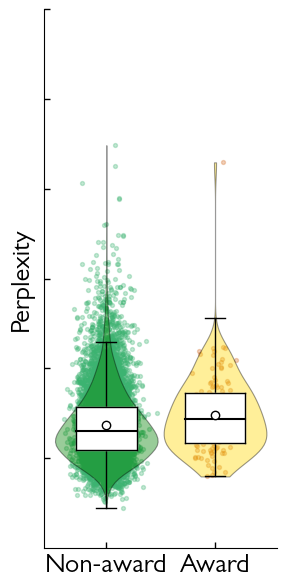

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind

import matplotlib.font_manager as fm

file_path = "./semantic_scholar_ppl_award_olmo7b.parquet"
df = pd.read_parquet(file_path)

award_papers = df[df['is_award'] == 1]['perplexity']
non_award_papers = df[df['is_award'] == 0]['perplexity']

data_to_plot = [non_award_papers, award_papers]
labels = ['Non-award', 'Award']

plt.figure(figsize=(3, 7))

plt.rcParams['axes.grid'] = False

positions = [0.5, 0.518]

colors = ['mediumseagreen', 'chocolate']
for i, data in enumerate(data_to_plot):
    x = np.random.normal(positions[i], 0.002, size=len(data))
    plt.scatter(x, data, alpha=0.3, s=8, color=colors[i], zorder=1)

violin_width = 0.017
violin_parts = plt.violinplot(data_to_plot, positions=positions, 
                             showmeans=False, showmedians=False, 
                             showextrema=False, widths=violin_width)
violin_colors = ['green', 'gold']
for i, pc in enumerate(violin_parts['bodies']):
    pc.set_facecolor(violin_colors[i])
    pc.set_edgecolor('black')
    pc.set_alpha(0.4)
    pc.set_linewidth(0.8)

box_width = 0.01
box_color = 'white'
means = []

for i, data in enumerate(data_to_plot):
    pos = positions[i]
    
    q1, median, q3 = np.percentile(data, [25, 50, 75])
    iqr = q3 - q1
    whisker_min = max(np.min(data), q1 - 1.5 * iqr)
    whisker_max = min(np.max(data), q3 + 1.5 * iqr)
    
    means.append(np.mean(data))
    
    plt.plot([pos-box_width/2, pos+box_width/2], [q1, q1], color='black', linewidth=1, zorder=7)
    plt.plot([pos-box_width/2, pos+box_width/2], [q3, q3], color='black', linewidth=1, zorder=7)
    plt.plot([pos-box_width/2, pos-box_width/2], [q1, q3], color='black', linewidth=1, zorder=7)
    plt.plot([pos+box_width/2, pos+box_width/2], [q1, q3], color='black', linewidth=1, zorder=7)
    
    plt.fill_between([pos-box_width/2, pos+box_width/2], [q1, q1], [q3, q3], color=box_color, zorder=5)
    
    plt.plot([pos-box_width/2, pos+box_width/2], [median, median], color='black', linewidth=1.5, zorder=8)
    
    plt.plot([pos, pos], [q1, whisker_min], color='black', linestyle='-', linewidth=1, zorder=4)
    plt.plot([pos, pos], [q3, whisker_max], color='black', linestyle='-', linewidth=1, zorder=4)
    
    whisker_cap = box_width/3
    plt.plot([pos-whisker_cap/2, pos+whisker_cap/2], [whisker_min, whisker_min], color='black', linewidth=1, zorder=4)
    plt.plot([pos-whisker_cap/2, pos+whisker_cap/2], [whisker_max, whisker_max], color='black', linewidth=1, zorder=4)

for i, pos in enumerate(positions):
    plt.plot(pos, means[i], 'o', color='white', markersize=6, markeredgecolor='black', markeredgewidth=1, zorder=9)

plt.xticks(positions, labels, fontsize=19)
plt.ylabel('Perplexity', fontsize=19)

ax = plt.gca()

ax.tick_params(axis='both', which='both', direction='in', colors='black', length=4, width=1)

yticks_positions = ax.get_yticks()

for i, tick_val in enumerate(yticks_positions):
    if abs(tick_val - 0) < 1e-10:
        tick_lines = ax.yaxis.get_majorticklines()
        if i*2 < len(tick_lines):
            tick_lines[i*2].set_markersize(0)
            tick_lines[i*2].set_markeredgewidth(0)
        if i*2+1 < len(tick_lines):
            tick_lines[i*2+1].set_markersize(0)
            tick_lines[i*2+1].set_markeredgewidth(0)

plt.yticks(fontsize=17)
for spine in ax.spines.values():
    spine.set_color('black')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.ylim(0, 60)
ax.set_yticklabels([])

plt.show()

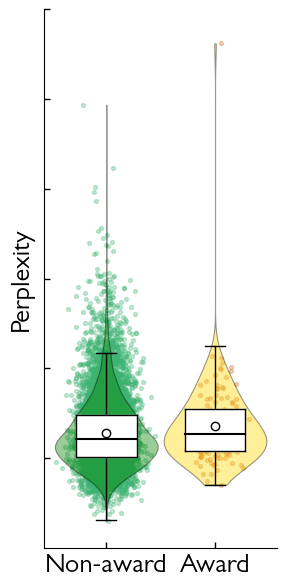

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind

import matplotlib.font_manager as fm

file_path = "./semantic_scholar_ppl_award_llama3.parquet"
df = pd.read_parquet(file_path)

award_papers = df[df['is_award'] == 1]['perplexity']
non_award_papers = df[df['is_award'] == 0]['perplexity']

data_to_plot = [non_award_papers, award_papers]
labels = ['Non-award', 'Award']

plt.figure(figsize=(3, 7))

plt.rcParams['axes.grid'] = False

positions = [0.5, 0.518]

colors = ['mediumseagreen', 'chocolate']
for i, data in enumerate(data_to_plot):
    x = np.random.normal(positions[i], 0.002, size=len(data))
    plt.scatter(x, data, alpha=0.3, s=8, color=colors[i], zorder=1)

violin_width = 0.017
violin_parts = plt.violinplot(data_to_plot, positions=positions, 
                             showmeans=False, showmedians=False, 
                             showextrema=False, widths=violin_width)
violin_colors = ['green', 'gold']
for i, pc in enumerate(violin_parts['bodies']):
    pc.set_facecolor(violin_colors[i])
    pc.set_edgecolor('black')
    pc.set_alpha(0.4)
    pc.set_linewidth(0.8)

box_width = 0.01
box_color = 'white'
means = []

for i, data in enumerate(data_to_plot):
    pos = positions[i]
    
    q1, median, q3 = np.percentile(data, [25, 50, 75])
    iqr = q3 - q1
    whisker_min = max(np.min(data), q1 - 1.5 * iqr)
    whisker_max = min(np.max(data), q3 + 1.5 * iqr)
    
    means.append(np.mean(data))
    
    plt.plot([pos-box_width/2, pos+box_width/2], [q1, q1], color='black', linewidth=1, zorder=7)
    plt.plot([pos-box_width/2, pos+box_width/2], [q3, q3], color='black', linewidth=1, zorder=7)
    plt.plot([pos-box_width/2, pos-box_width/2], [q1, q3], color='black', linewidth=1, zorder=7)
    plt.plot([pos+box_width/2, pos+box_width/2], [q1, q3], color='black', linewidth=1, zorder=7)
    
    plt.fill_between([pos-box_width/2, pos+box_width/2], [q1, q1], [q3, q3], color=box_color, zorder=5)
    
    plt.plot([pos-box_width/2, pos+box_width/2], [median, median], color='black', linewidth=1.5, zorder=8)
    
    plt.plot([pos, pos], [q1, whisker_min], color='black', linestyle='-', linewidth=1, zorder=4)
    plt.plot([pos, pos], [q3, whisker_max], color='black', linestyle='-', linewidth=1, zorder=4)
    
    whisker_cap = box_width/3
    plt.plot([pos-whisker_cap/2, pos+whisker_cap/2], [whisker_min, whisker_min], color='black', linewidth=1, zorder=4)
    plt.plot([pos-whisker_cap/2, pos+whisker_cap/2], [whisker_max, whisker_max], color='black', linewidth=1, zorder=4)

for i, pos in enumerate(positions):
    plt.plot(pos, means[i], 'o', color='white', markersize=6, markeredgecolor='black', markeredgewidth=1, zorder=9)

plt.xticks(positions, labels, fontsize=19)
plt.ylabel('Perplexity', fontsize=19)

ax = plt.gca()

ax.tick_params(axis='both', which='both', direction='in', colors='black', length=4, width=1)

yticks_positions = ax.get_yticks()

for i, tick_val in enumerate(yticks_positions):
    if abs(tick_val - 0) < 1e-10:
        tick_lines = ax.yaxis.get_majorticklines()
        if i*2 < len(tick_lines):
            tick_lines[i*2].set_markersize(0)
            tick_lines[i*2].set_markeredgewidth(0)
        if i*2+1 < len(tick_lines):
            tick_lines[i*2+1].set_markersize(0)
            tick_lines[i*2+1].set_markeredgewidth(0)

plt.yticks(fontsize=17)
for spine in ax.spines.values():
    spine.set_color('black')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.ylim(0, 60)
ax.set_yticklabels([])

plt.show()

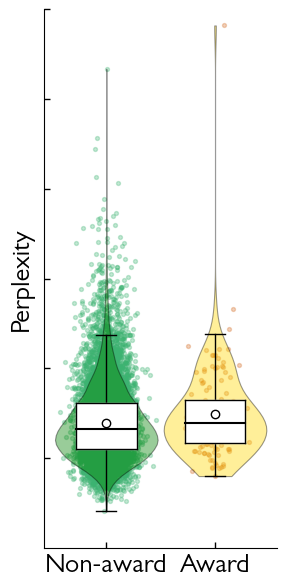

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind

import matplotlib.font_manager as fm

file_path = "./semantic_scholar_ppl_award_deepseek.parquet"
df = pd.read_parquet(file_path)

award_papers = df[df['is_award'] == 1]['perplexity']
non_award_papers = df[df['is_award'] == 0]['perplexity']

data_to_plot = [non_award_papers, award_papers]
labels = ['Non-award', 'Award']

plt.figure(figsize=(3, 7))

plt.rcParams['axes.grid'] = False

positions = [0.5, 0.518]

colors = ['mediumseagreen', 'chocolate']
for i, data in enumerate(data_to_plot):
    x = np.random.normal(positions[i], 0.002, size=len(data))
    plt.scatter(x, data, alpha=0.3, s=8, color=colors[i], zorder=1)

violin_width = 0.017
violin_parts = plt.violinplot(data_to_plot, positions=positions, 
                             showmeans=False, showmedians=False, 
                             showextrema=False, widths=violin_width)
violin_colors = ['green', 'gold']
for i, pc in enumerate(violin_parts['bodies']):
    pc.set_facecolor(violin_colors[i])
    pc.set_edgecolor('black')
    pc.set_alpha(0.4)
    pc.set_linewidth(0.8)

box_width = 0.01
box_color = 'white'
means = []

for i, data in enumerate(data_to_plot):
    pos = positions[i]
    
    q1, median, q3 = np.percentile(data, [25, 50, 75])
    iqr = q3 - q1
    whisker_min = max(np.min(data), q1 - 1.5 * iqr)
    whisker_max = min(np.max(data), q3 + 1.5 * iqr)
    
    means.append(np.mean(data))
    
    plt.plot([pos-box_width/2, pos+box_width/2], [q1, q1], color='black', linewidth=1, zorder=7)
    plt.plot([pos-box_width/2, pos+box_width/2], [q3, q3], color='black', linewidth=1, zorder=7)
    plt.plot([pos-box_width/2, pos-box_width/2], [q1, q3], color='black', linewidth=1, zorder=7)
    plt.plot([pos+box_width/2, pos+box_width/2], [q1, q3], color='black', linewidth=1, zorder=7)
    
    plt.fill_between([pos-box_width/2, pos+box_width/2], [q1, q1], [q3, q3], color=box_color, zorder=5)
    
    plt.plot([pos-box_width/2, pos+box_width/2], [median, median], color='black', linewidth=1.5, zorder=8)
    
    plt.plot([pos, pos], [q1, whisker_min], color='black', linestyle='-', linewidth=1, zorder=4)
    plt.plot([pos, pos], [q3, whisker_max], color='black', linestyle='-', linewidth=1, zorder=4)
    
    whisker_cap = box_width/3
    plt.plot([pos-whisker_cap/2, pos+whisker_cap/2], [whisker_min, whisker_min], color='black', linewidth=1, zorder=4)
    plt.plot([pos-whisker_cap/2, pos+whisker_cap/2], [whisker_max, whisker_max], color='black', linewidth=1, zorder=4)

for i, pos in enumerate(positions):
    plt.plot(pos, means[i], 'o', color='white', markersize=6, markeredgecolor='black', markeredgewidth=1, zorder=9)

plt.xticks(positions, labels, fontsize=19)
plt.ylabel('Perplexity', fontsize=19)

ax = plt.gca()

ax.tick_params(axis='both', which='both', direction='in', colors='black', length=4, width=1)

yticks_positions = ax.get_yticks()

for i, tick_val in enumerate(yticks_positions):
    if abs(tick_val - 0) < 1e-10:
        tick_lines = ax.yaxis.get_majorticklines()
        if i*2 < len(tick_lines):
            tick_lines[i*2].set_markersize(0)
            tick_lines[i*2].set_markeredgewidth(0)
        if i*2+1 < len(tick_lines):
            tick_lines[i*2+1].set_markersize(0)
            tick_lines[i*2+1].set_markeredgewidth(0)

plt.yticks(fontsize=17)
for spine in ax.spines.values():
    spine.set_color('black')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.ylim(0, 60)
ax.set_yticklabels([])

plt.show()

In [ ]:
# Fig. 3d

/scratch/local/jobs/59349233/ipykernel_1251198/3655733694.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_filtered.groupby(['perplexity_bin', 'funding_institute_split']).size().reset_index(name='count')
/scratch/local/jobs/59349233/ipykernel_1251198/3655733694.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_filtered.groupby(['perplexity_bin', 'funding_institute_split']).size().reset_index(name='count')
/scratch/local/jobs/59349233/ipykernel_1251198/3655733694.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of

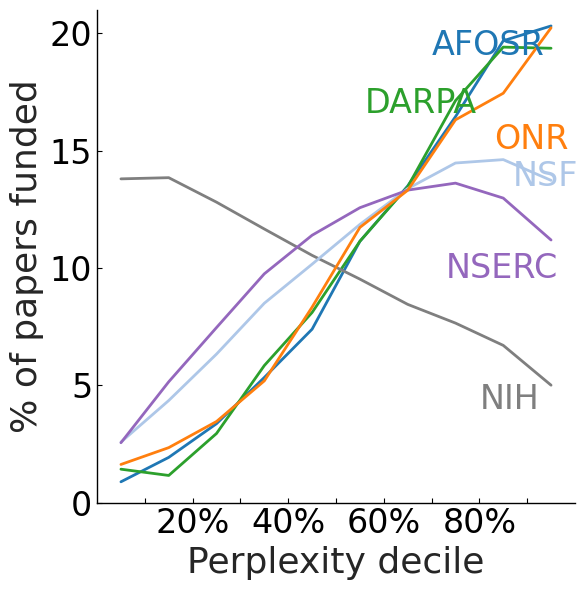

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

file_path = "./4_ppl_funding_institution.parquet"

ppl_cols = ['perplexity_olmo1b', 'perplexity_olmo7b', 'perplexity_llama3', 'perplexity_deepseek']

target_institutes = ['afosr', 'darpa', 'nih', 'nsf', 'nserc', 'onr']

all_pivot_dfs = []

df_raw = pd.read_parquet(file_path)

for ppl_col in ppl_cols:
    df = df_raw.dropna(subset=[ppl_col]).copy()
    df['perplexity_bin'] = pd.qcut(df[ppl_col], 10, duplicates='drop')

    df_fund = df.dropna(subset=['funding_institute']).copy()
    df_fund = df_fund.assign(
        funding_institute_split=df_fund['funding_institute'].str.split(';')
                                      .apply(lambda lst: [x.strip() for x in lst if x and x.strip() != ''])
    )
    df_combined = df_fund.explode('funding_institute_split')
    
    total_counts = df_combined['funding_institute_split'].value_counts()
    valid_institutes = total_counts[total_counts >= 1].index
    df_filtered = df_combined[df_combined['funding_institute_split'].isin(valid_institutes)]
    
    grouped = df_filtered.groupby(['perplexity_bin', 'funding_institute_split']).size().reset_index(name='count')
    grouped['proportion'] = grouped.apply(
        lambda row: row['count'] / total_counts[row['funding_institute_split']],
        axis=1
    )
    pivot_df = grouped.pivot(index='perplexity_bin', columns='funding_institute_split', values='proportion')
    available_institutes = [inst for inst in target_institutes if inst in pivot_df.columns]
    pivot_df_filtered = pivot_df[available_institutes].fillna(0)

    pivot_df_filtered = pivot_df_filtered.sort_index().reset_index(drop=True)
    all_pivot_dfs.append(pivot_df_filtered)

avg_df = pd.concat(all_pivot_dfs).groupby(level=0).mean() * 100

fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

institute_colors = {
    'afosr': '#1f77b4',
    'darpa': '#2ca02c', 
    'nih': '#7f7f7f',
    'nsf': '#aec7e8',
    'nserc': '#9467bd',
    'onr': '#ff7f0e'
}

x_positions = np.arange(5, 100, 10)

all_y_values = []

for i, col in enumerate(avg_df.columns):
    color = institute_colors.get(col, '#000000')
    y_values = avg_df[col].values
    all_y_values.extend(y_values)
    ax.plot(x_positions, y_values, color=color, linewidth=2)

non_zero_y_values = [y for y in all_y_values if y > 0]
if non_zero_y_values:
    y_min = min(non_zero_y_values)
    y_max = max(all_y_values)
    y_margin = (y_max - y_min) * 0.05
    y_min_adjusted = max(0, y_min - y_margin)
    y_max_adjusted = y_max + y_margin
    ax.set_ylim(0, y_max_adjusted)

ax.set_xlim(0, 100)
ax.set_ylim(0, 21)

tick_positions = np.arange(10, 100, 10)
label_positions = [20, 40, 60, 80]
tick_labels = [f'{i}%' if i in label_positions else '' for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)

ax.set_xlabel('Perplexity decile', fontsize=26)
ax.set_ylabel('% of papers funded', fontsize=26)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)
ax.tick_params(axis='both', direction='in', colors='black')
ax.grid(False)
ax.xaxis.set_tick_params(labelsize=24)
ax.yaxis.set_tick_params(labelsize=24)

text_positions = {
    'afosr': (70, 19.5),
    'darpa': (56, 17),
    'nih': (80, 4.4),
    'nsf': (87, 13.9),
    'nserc': (73, 10),
    'onr': (83, 15.48)
}

for i, col in enumerate(avg_df.columns):
    color = institute_colors.get(col, '#000000')
    text_x, text_y = text_positions.get(col, (-12, 95 - i*8))
    
    if col == 'onr':
        label_text = 'ONR'
    else:
        label_text = col.upper()
    
    ax.text(text_x, text_y, label_text, color=color, fontsize=24,
            verticalalignment='center', horizontalalignment='left')

plt.tight_layout()
plt.show()

In [ ]:
# Fig. 3e

/scratch/local/jobs/59349233/ipykernel_1251198/1547885073.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_filtered.groupby(['perplexity_bin', 'funding_institute_split']).size().reset_index(name='count')
/scratch/local/jobs/59349233/ipykernel_1251198/1547885073.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_filtered.groupby(['perplexity_bin', 'funding_institute_split']).size().reset_index(name='count')
/scratch/local/jobs/59349233/ipykernel_1251198/1547885073.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of

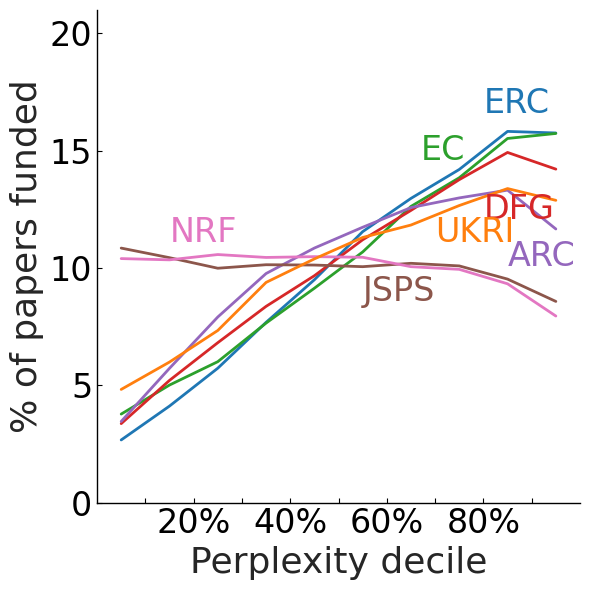

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

file_path = "./4_ppl_funding_institution.parquet"

ppl_cols = ['perplexity_olmo1b', 'perplexity_olmo7b', 'perplexity_llama3', 'perplexity_deepseek']

target_institutes = ['erc', 'ec', 'dfg', 'arc', 'jsps', 'nrf', 'ukri']

all_pivot_dfs = []

df_raw = pd.read_parquet(file_path)

for ppl_col in ppl_cols:
    df = df_raw.dropna(subset=[ppl_col]).copy()
    df['perplexity_bin'] = pd.qcut(df[ppl_col], 10, duplicates='drop')

    df_fund = df.dropna(subset=['funding_institute']).copy()
    df_fund = df_fund.assign(
        funding_institute_split=df_fund['funding_institute'].str.split(';')
                                      .apply(lambda lst: [x.strip() for x in lst if x and x.strip() != ''])
    )
    df_combined = df_fund.explode('funding_institute_split')
    
    total_counts = df_combined['funding_institute_split'].value_counts()
    valid_institutes = total_counts[total_counts >= 1].index
    df_filtered = df_combined[df_combined['funding_institute_split'].isin(valid_institutes)]
    
    grouped = df_filtered.groupby(['perplexity_bin', 'funding_institute_split']).size().reset_index(name='count')
    grouped['proportion'] = grouped.apply(
        lambda row: row['count'] / total_counts[row['funding_institute_split']],
        axis=1
    )
    pivot_df = grouped.pivot(index='perplexity_bin', columns='funding_institute_split', values='proportion')
    available_institutes = [inst for inst in target_institutes if inst in pivot_df.columns]
    pivot_df_filtered = pivot_df[available_institutes].fillna(0)

    pivot_df_filtered = pivot_df_filtered.sort_index().reset_index(drop=True)
    all_pivot_dfs.append(pivot_df_filtered)

avg_df = pd.concat(all_pivot_dfs).groupby(level=0).mean() * 100

fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

institute_colors = {
    'erc': '#1f77b4',
    'ec': '#2ca02c', 
    'dfg': '#d62728',
    'arc': '#9467bd',
    'jsps': '#8c564b',
    'nrf': '#e377c2',
    'ukri': '#ff7f0e'
}

x_positions = np.arange(5, 100, 10)

all_y_values = []

for i, col in enumerate(avg_df.columns):
    color = institute_colors.get(col, '#000000')
    y_values = avg_df[col].values
    all_y_values.extend(y_values)
    ax.plot(x_positions, y_values, color=color, linewidth=2)

non_zero_y_values = [y for y in all_y_values if y > 0]
if non_zero_y_values:
    y_min = min(non_zero_y_values)
    y_max = max(all_y_values)
    y_margin = (y_max - y_min) * 0.05
    y_min_adjusted = max(0, y_min - y_margin)
    y_max_adjusted = y_max + y_margin
    ax.set_ylim(0, y_max_adjusted)

ax.set_xlim(0, 100)
ax.set_ylim(0, 21)

tick_positions = np.arange(10, 100, 10)
label_positions = [20, 40, 60, 80]
tick_labels = [f'{i}%' if i in label_positions else '' for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)

ax.set_xlabel('Perplexity decile', fontsize=26)
ax.set_ylabel('% of papers funded', fontsize=26)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)
ax.tick_params(axis='both', direction='in', colors='black')
ax.grid(False)
ax.xaxis.set_tick_params(labelsize=24)
ax.yaxis.set_tick_params(labelsize=24)

text_positions = {
    'erc': (80, 17),
    'ec': (67, 15),
    'dfg': (80, 12.5),
    'ukri': (70, 11.5),
    'jsps': (55, 9),
    'nrf': (15, 11.5),
    'arc': (85, 10.5)
}

for i, col in enumerate(avg_df.columns):
    color = institute_colors.get(col, '#000000')

    default_x = 83
    default_y = avg_df[col].iloc[-1] if len(avg_df[col]) > 0 else 10
    
    text_x, text_y = text_positions.get(col, (default_x, default_y))
    label_text = col.upper()
    
    ax.text(text_x, text_y, label_text, color=color, fontsize=24,
            verticalalignment='center', horizontalalignment='left')

plt.tight_layout()
plt.show()

In [ ]:
# Fig. 4a

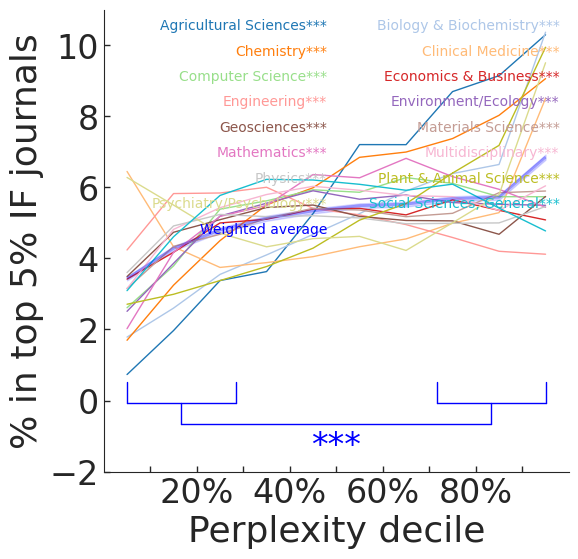

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import matplotlib
import matplotlib.font_manager as fm
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

data_dir = "./data_field/"
file_paths = glob.glob(os.path.join(data_dir, "*_perplexity.parquet"))

cmap = matplotlib.colormaps.get_cmap("tab20")
colors = [cmap(i / len(file_paths)) for i in range(len(file_paths))]

label_mapping = {
    'agricultural_science': 'Agricultural Sciences***',
    'biology_biochemistry': 'Biology & Biochemistry***',
    'chemistry': 'Chemistry***',
    'clinical_medicine': 'Clinical Medicine***',
    'computer_science': 'Computer Science***',
    'economics_business': 'Economics & Business***',
    'engineering': 'Engineering***',
    'environment_ecology': 'Environment/Ecology***',
    'geosciences': 'Geosciences***',
    'materials_science': 'Materials Science***',
    'mathematics': 'Mathematics***',
    'multidisciplinary': 'Multidisciplinary***',
    'physics': 'Physics***',
    'plant_animal_science': 'Plant & Animal Science***',
    'psychiatry_psychology': 'Psychiatry/Psychology***',
    'social_sciences_general': 'Social Sciences, General***'
}

def bootstrap_confidence_interval(data, percentile=95, n_bootstrap=1000):
    if len(data) == 0:
        return 0, 0
    
    alpha = (100 - percentile) / 100
    
    bootstrap_samples = np.random.choice(data, size=(n_bootstrap, len(data)), replace=True)
    bootstrap_means = np.mean(bootstrap_samples, axis=1)
    
    lower_bound = np.percentile(bootstrap_means, alpha/2 * 100)
    upper_bound = np.percentile(bootstrap_means, (1 - alpha/2) * 100)
    
    return lower_bound, upper_bound

def bootstrap_confidence_interval_stratified(data_by_group, group_weights=None, percentile=95, n_bootstrap=1000):
    data_by_group = {group: data for group, data in data_by_group.items() if data}
    
    if not data_by_group:
        return 0, 0
    
    alpha = (100 - percentile) / 100
    
    if group_weights is None:
        group_weights = {group: 1/len(data_by_group) for group in data_by_group}
    
    total_weight = sum(group_weights[group] for group in data_by_group if group in group_weights)
    if total_weight > 0:
        normalized_weights = {group: weight/total_weight for group, weight in group_weights.items() 
                              if group in data_by_group}
    else:
        normalized_weights = {group: 1/len(data_by_group) for group in data_by_group}
    
    bootstrap_means = []
    for _ in range(n_bootstrap):
        group_means = {}
        for group, data in data_by_group.items():
            if data:
                resampled_data = np.random.choice(data, size=len(data), replace=True)
                group_means[group] = np.mean(resampled_data)
        
        weighted_mean = sum(group_means[group] * normalized_weights[group] for group in group_means)
        bootstrap_means.append(weighted_mean)
    
    lower_bound = np.percentile(bootstrap_means, alpha/2 * 100)
    upper_bound = np.percentile(bootstrap_means, (1 - alpha/2) * 100)
    
    return lower_bound, upper_bound

def plot_data(file_list, title_suffix, main_ax=None):
    if main_ax is None:
        plt.figure(figsize=(6, 6))
        main_ax = plt.gca()
    
    sns.set_style("ticks")
    
    legend_labels = []
    legend_colors = []
    
    all_bin_data = {bin_idx: [] for bin_idx in range(10)}
    all_y_values = []
    
    bin_data_by_file = {bin_idx: {} for bin_idx in range(10)}
    bin_weights = {bin_idx: {} for bin_idx in range(10)}
    
    for idx, file_path in enumerate(sorted(file_list)):
        df = pd.read_parquet(file_path)        
        filename = os.path.basename(file_path)
        group_name = filename.replace("_perplexity.parquet", "")
        display_name = label_mapping.get(group_name, group_name)
        legend_labels.append(display_name)
        legend_colors.append(colors[idx])
        
        threshold_impact_factor = df['impact_factor_2y'].quantile(0.95)
        df['perplexity_bins'] = pd.qcut(df['perplexity'], 10, labels=False)
        percentages = []
        
        current_file_bootstrap_data = {bin_idx: [] for bin_idx in range(10)}
        
        for bin_idx in range(10):
            subset = df[df['perplexity_bins'] == bin_idx]
            bin_count = len(subset)
            
            if bin_count > 0:
                top_5_percent_impact_factor = subset[subset['impact_factor_2y'] >= threshold_impact_factor]
                percentage = len(top_5_percent_impact_factor) / bin_count * 100
                
                is_top_5_percent = np.zeros(bin_count)
                is_top_5_percent[:len(top_5_percent_impact_factor)] = 1
                np.random.shuffle(is_top_5_percent)
                
                all_bin_data[bin_idx].extend(is_top_5_percent * 100)
                
                bin_data_by_file[bin_idx][group_name] = list(is_top_5_percent * 100)
                bin_weights[bin_idx][group_name] = bin_count
                
                current_file_bootstrap_data[bin_idx] = list(is_top_5_percent * 100)
            else:
                percentage = 0
                bin_data_by_file[bin_idx][group_name] = []
                bin_weights[bin_idx][group_name] = 0
                current_file_bootstrap_data[bin_idx] = []
            
            mid_percent = (bin_idx + 0.5) * 10
            percentages.append((mid_percent, percentage))
        
        x_values = [x[0] for x in percentages]
        y_values = [x[1] for x in percentages]
        all_y_values.extend(y_values)
        
        main_ax.plot(x_values, y_values, color=colors[idx], linestyle='-', linewidth=1, alpha=1, label=display_name)
    
    weighted_avg_values = []
    
    for bin_idx in range(10):
        total_weight = sum(bin_weights[bin_idx].values())
        if total_weight > 0:
            weights = {group: count/total_weight for group, count in bin_weights[bin_idx].items()}
            weighted_mean = 0
            for group in bin_data_by_file[bin_idx]:
                if bin_data_by_file[bin_idx][group] and len(bin_data_by_file[bin_idx][group]) > 0:
                    group_mean = np.mean(bin_data_by_file[bin_idx][group])
                    weighted_mean += group_mean * weights[group]
            
            weighted_avg_values.append(weighted_mean)
        else:
            weighted_avg_values.append(0)
    
    weighted_avg_lower_bounds = []
    weighted_avg_upper_bounds = []
    for bin_idx in range(10):
        if bin_data_by_file[bin_idx]:
            weights_for_bootstrap = {group: bin_weights[bin_idx][group] for group in bin_data_by_file[bin_idx]}
            lower, upper = bootstrap_confidence_interval_stratified(
                bin_data_by_file[bin_idx], 
                group_weights=weights_for_bootstrap, 
                percentile=95, 
                n_bootstrap=1000
            )
            weighted_avg_lower_bounds.append(lower)
            weighted_avg_upper_bounds.append(upper)
        else:
            weighted_avg_lower_bounds.append(0)
            weighted_avg_upper_bounds.append(0)
    
    x_values_avg = [(bin_idx + 0.5) * 10 for bin_idx in range(10)]
    all_y_values.extend(weighted_avg_values)
    all_y_values.extend(weighted_avg_lower_bounds)
    all_y_values.extend(weighted_avg_upper_bounds)
    
    main_ax.fill_between(x_values_avg, weighted_avg_lower_bounds, weighted_avg_upper_bounds, color='blue', alpha=0.15)
    
    main_ax.plot(x_values_avg, weighted_avg_values, color='blue', linestyle='-', linewidth=2, alpha=0.3, label='Weighted average', solid_capstyle='butt')
    
    y_min_bottom = min(all_y_values)
    y_base_lower = y_min_bottom - 0.2
    
    lower_left_bracket_width = 23.33
    lower_right_bracket_width = 23.33
    lower_bracket_height = 0.6
    lower_top_bracket_height = 0.6
    lower_vertical_gap = 0
    
    x_left_center = 16.665
    x_right_center = 83.335
    
    x_left_start_lower = x_left_center - lower_left_bracket_width/2
    x_left_end_lower = x_left_center + lower_left_bracket_width/2
    x_right_start_lower = x_right_center - lower_right_bracket_width/2
    x_right_end_lower = x_right_center + lower_right_bracket_width/2
    
    main_ax.plot([x_left_start_lower, x_left_start_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')
    main_ax.plot([x_left_start_lower, x_left_end_lower], [y_base_lower - lower_bracket_height, y_base_lower - lower_bracket_height], linewidth=1, color='blue')
    main_ax.plot([x_left_end_lower, x_left_end_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')
    
    main_ax.plot([x_right_start_lower, x_right_start_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')
    main_ax.plot([x_right_start_lower, x_right_end_lower], [y_base_lower - lower_bracket_height, y_base_lower - lower_bracket_height], linewidth=1, color='blue')
    main_ax.plot([x_right_end_lower, x_right_end_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')
    
    y_top_base_lower = y_base_lower - lower_bracket_height - lower_vertical_gap
    y_top_top_lower = y_top_base_lower - lower_top_bracket_height
    
    main_ax.plot([x_left_center, x_left_center], [y_base_lower - lower_bracket_height, y_top_base_lower], linewidth=1, color='blue')
    main_ax.plot([x_right_center, x_right_center], [y_base_lower - lower_bracket_height, y_top_base_lower], linewidth=1, color='blue')
    
    main_ax.plot([x_left_center, x_left_center], [y_top_base_lower, y_top_top_lower], linewidth=1, color='blue')
    main_ax.plot([x_left_center, x_right_center], [y_top_top_lower, y_top_top_lower], linewidth=1, color='blue')
    main_ax.plot([x_right_center, x_right_center], [y_top_top_lower, y_top_base_lower], linewidth=1, color='blue')
    
    main_ax.text((x_left_center + x_right_center) / 2, y_top_top_lower - 0.15, "***", 
                 ha='center', va='top', fontsize=24, color='blue')
    
    x_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
    main_ax.set_xticks(x_ticks)
    main_ax.set_xticklabels([
        "20%" if i == 20 else
        "40%" if i == 40 else
        "60%" if i == 60 else
        "80%" if i == 80 else
        ""
        for i in x_ticks
    ])
    
    main_ax.set_xlim(0, 100)
    
    main_ax.set_xlabel("Perplexity decile", fontsize=26)
    main_ax.set_ylabel("% in top 5% IF journals", fontsize=26)
    
    main_ax.spines['top'].set_visible(False)
    main_ax.spines['right'].set_visible(False)
    main_ax.tick_params(axis='both', which='both', direction='in', length=4, width=1)
    
    y_plot_min = min(y_top_top_lower - 0.3, min(all_y_values) - 1)
    y_plot_max = max(all_y_values) + 0.5
    main_ax.set_ylim(y_plot_min, y_plot_max)
    
    main_ax.tick_params(axis='both', labelsize=24)
    
    main_ax.set_ylim(-0.9, 11)
    main_ax.set_yticks([-2, 0, 2, 4, 6, 8, 10])
    
    main_ax.grid(False)
    
    legend_labels.append('Weighted average')
    legend_colors.append('blue')
    
    n_cols = 2
    legend_x_list = [0.48, 0.98]
    legend_y = 0.98
    legend_spacing = 0.055
    
    for i, (label, color) in enumerate(zip(legend_labels, legend_colors)):
        col = i % n_cols
        row = i // n_cols
        
        x_pos = legend_x_list[col]
        y_pos = legend_y - row * legend_spacing
        
        main_ax.text(x_pos, y_pos, label, 
                    transform=main_ax.transAxes,
                    fontsize=10,
                    color=color,
                    ha='right', va='top')

fig, ax1 = plt.subplots(1, 1, figsize=(6, 6))

plot_data(file_paths, "All Files", ax1)

plt.show()

In [ ]:
# Fig. 4b

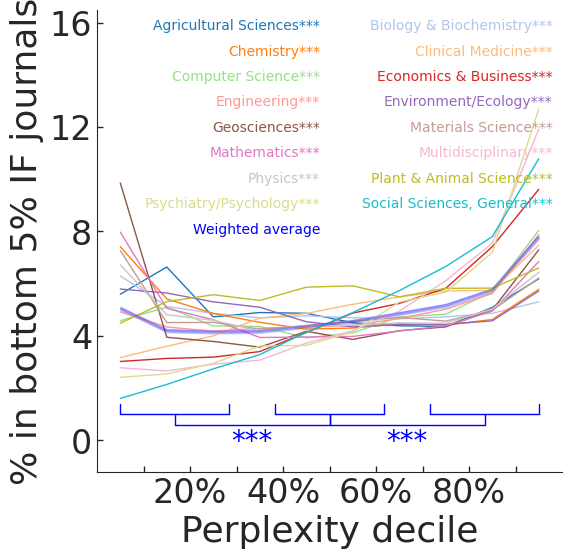

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import matplotlib
import matplotlib.font_manager as fm
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

data_dir = "./data_field/"
file_paths = glob.glob(os.path.join(data_dir, "*_perplexity.parquet"))

cmap = matplotlib.colormaps.get_cmap("tab20")
colors = [cmap(i / len(file_paths)) for i in range(len(file_paths))]

label_mapping = {
    'agricultural_science': 'Agricultural Sciences***',
    'biology_biochemistry': 'Biology & Biochemistry***',
    'chemistry': 'Chemistry***',
    'clinical_medicine': 'Clinical Medicine***',
    'computer_science': 'Computer Science***',
    'economics_business': 'Economics & Business***',
    'engineering': 'Engineering***',
    'environment_ecology': 'Environment/Ecology***',
    'geosciences': 'Geosciences***',
    'materials_science': 'Materials Science***',
    'mathematics': 'Mathematics***',
    'multidisciplinary': 'Multidisciplinary***',
    'physics': 'Physics***',
    'plant_animal_science': 'Plant & Animal Science***',
    'psychiatry_psychology': 'Psychiatry/Psychology***',
    'social_sciences_general': 'Social Sciences, General***'
}

def bootstrap_confidence_interval(data, percentile=95, n_bootstrap=1000):
    if len(data) == 0:
        return 0, 0
    
    alpha = (100 - percentile) / 100
    
    bootstrap_samples = np.random.choice(data, size=(n_bootstrap, len(data)), replace=True)
    bootstrap_means = np.mean(bootstrap_samples, axis=1)
    
    lower_bound = np.percentile(bootstrap_means, alpha/2 * 100)
    upper_bound = np.percentile(bootstrap_means, (1 - alpha/2) * 100)
    
    return lower_bound, upper_bound

def bootstrap_confidence_interval_stratified(data_by_group, group_weights=None, percentile=95, n_bootstrap=1000):
    data_by_group = {group: data for group, data in data_by_group.items() if data}
    
    if not data_by_group:
        return 0, 0
    
    alpha = (100 - percentile) / 100
    
    if group_weights is None:
        group_weights = {group: 1/len(data_by_group) for group in data_by_group}
    
    total_weight = sum(group_weights[group] for group in data_by_group if group in group_weights)
    if total_weight > 0:
        normalized_weights = {group: weight/total_weight for group, weight in group_weights.items() 
                              if group in data_by_group}
    else:
        normalized_weights = {group: 1/len(data_by_group) for group in data_by_group}
    
    bootstrap_means = []
    for _ in range(n_bootstrap):
        group_means = {}
        for group, data in data_by_group.items():
            if data:
                resampled_data = np.random.choice(data, size=len(data), replace=True)
                group_means[group] = np.mean(resampled_data)
        
        weighted_mean = sum(group_means[group] * normalized_weights[group] for group in group_means)
        bootstrap_means.append(weighted_mean)
    
    lower_bound = np.percentile(bootstrap_means, alpha/2 * 100)
    upper_bound = np.percentile(bootstrap_means, (1 - alpha/2) * 100)
    
    return lower_bound, upper_bound

def plot_data(file_list, title_suffix, main_ax=None):
    if main_ax is None:
        plt.figure(figsize=(6, 6))
        main_ax = plt.gca()
    
    sns.set_style("ticks")
    
    legend_labels = []
    legend_colors = []
    
    all_bin_data = {bin_idx: [] for bin_idx in range(10)}
    all_y_values = []
    
    bin_data_by_file = {bin_idx: {} for bin_idx in range(10)}
    bin_weights = {bin_idx: {} for bin_idx in range(10)}
    
    for idx, file_path in enumerate(sorted(file_list)):
        df = pd.read_parquet(file_path)        
        filename = os.path.basename(file_path)
        group_name = filename.replace("_perplexity.parquet", "")
        display_name = label_mapping.get(group_name, group_name)
        legend_labels.append(display_name)
        legend_colors.append(colors[idx])
        
        threshold_impact_factor = df['impact_factor_2y'].quantile(0.05)
        df['perplexity_bins'] = pd.qcut(df['perplexity'], 10, labels=False)
        percentages = []
        
        current_file_bootstrap_data = {bin_idx: [] for bin_idx in range(10)}
        
        for bin_idx in range(10):
            subset = df[df['perplexity_bins'] == bin_idx]
            bin_count = len(subset)
            
            if bin_count > 0:
                top_5_percent_impact_factor = subset[subset['impact_factor_2y'] <= threshold_impact_factor]
                percentage = len(top_5_percent_impact_factor) / bin_count * 100
                
                is_top_5_percent = np.zeros(bin_count)
                is_top_5_percent[:len(top_5_percent_impact_factor)] = 1
                np.random.shuffle(is_top_5_percent)
                
                all_bin_data[bin_idx].extend(is_top_5_percent * 100)
                
                bin_data_by_file[bin_idx][group_name] = list(is_top_5_percent * 100)
                bin_weights[bin_idx][group_name] = bin_count
                
                current_file_bootstrap_data[bin_idx] = list(is_top_5_percent * 100)
            else:
                percentage = 0
                bin_data_by_file[bin_idx][group_name] = []
                bin_weights[bin_idx][group_name] = 0
                current_file_bootstrap_data[bin_idx] = []
            
            mid_percent = (bin_idx + 0.5) * 10
            percentages.append((mid_percent, percentage))
        
        x_values = [x[0] for x in percentages]
        y_values = [x[1] for x in percentages]
        all_y_values.extend(y_values)
        
        main_ax.plot(x_values, y_values, color=colors[idx], linestyle='-', linewidth=1, alpha=1, label=display_name)
    
    weighted_avg_values = []
    
    for bin_idx in range(10):
        total_weight = sum(bin_weights[bin_idx].values())
        if total_weight > 0:
            weights = {group: count/total_weight for group, count in bin_weights[bin_idx].items()}
            weighted_mean = 0
            for group in bin_data_by_file[bin_idx]:
                if bin_data_by_file[bin_idx][group] and len(bin_data_by_file[bin_idx][group]) > 0:
                    group_mean = np.mean(bin_data_by_file[bin_idx][group])
                    weighted_mean += group_mean * weights[group]
            
            weighted_avg_values.append(weighted_mean)
        else:
            weighted_avg_values.append(0)
    
    weighted_avg_lower_bounds = []
    weighted_avg_upper_bounds = []
    for bin_idx in range(10):
        if bin_data_by_file[bin_idx]:
            weights_for_bootstrap = {group: bin_weights[bin_idx][group] for group in bin_data_by_file[bin_idx]}
            lower, upper = bootstrap_confidence_interval_stratified(
                bin_data_by_file[bin_idx], 
                group_weights=weights_for_bootstrap, 
                percentile=95, 
                n_bootstrap=1000
            )
            weighted_avg_lower_bounds.append(lower)
            weighted_avg_upper_bounds.append(upper)
        else:
            weighted_avg_lower_bounds.append(0)
            weighted_avg_upper_bounds.append(0)
    
    x_values_avg = [(bin_idx + 0.5) * 10 for bin_idx in range(10)]
    all_y_values.extend(weighted_avg_values)
    all_y_values.extend(weighted_avg_lower_bounds)
    all_y_values.extend(weighted_avg_upper_bounds)
    
    main_ax.fill_between(x_values_avg, weighted_avg_lower_bounds, weighted_avg_upper_bounds, color='blue', alpha=0.15)
    
    main_ax.plot(x_values_avg, weighted_avg_values, color='blue', linestyle='-', linewidth=2, alpha=0.3, label='Weighted average', solid_capstyle='butt')
    
    # ==================== 显著性标注部分（前 vs 中，中 vs 后） ====================
    y_min_bottom = min(all_y_values)
    y_base_lower = y_min_bottom - 0.2
    
    x_left_center = 16.665
    x_mid_center = 50.0
    x_right_center = 83.335
    
    lower_bracket_height = 0.4
    
    # 绘制左、中、右三个小框架
    for x_c in [x_left_center, x_mid_center, x_right_center]:
        x_start = x_c - 11.66
        x_end = x_c + 11.66
        main_ax.plot([x_start, x_start], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')
        main_ax.plot([x_end, x_end], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')
        main_ax.plot([x_start, x_end], [y_base_lower - lower_bracket_height, y_base_lower - lower_bracket_height], linewidth=1, color='blue')

    y_top_base = y_base_lower - lower_bracket_height
    y_top_line = y_top_base - 0.4
    
    # 1. 前 vs 中 (Left <-> Mid) 比较线与星号
    main_ax.plot([x_left_center, x_left_center], [y_top_base, y_top_line], linewidth=1, color='blue')
    main_ax.plot([x_mid_center, x_mid_center], [y_top_base, y_top_line], linewidth=1, color='blue')
    main_ax.plot([x_left_center, x_mid_center], [y_top_line, y_top_line], linewidth=1, color='blue')
    main_ax.text((x_left_center + x_mid_center) / 2, y_top_line - 0.1, "***", 
                 ha='center', va='top', fontsize=20, color='blue')

    # 2. 中 vs 后 (Mid <-> Right) 比较线与星号
    main_ax.plot([x_mid_center, x_mid_center], [y_top_base, y_top_line], linewidth=1, color='blue')
    main_ax.plot([x_right_center, x_right_center], [y_top_base, y_top_line], linewidth=1, color='blue')
    main_ax.plot([x_mid_center, x_right_center], [y_top_line, y_top_line], linewidth=1, color='blue')
    main_ax.text((x_mid_center + x_right_center) / 2, y_top_line - 0.1, "***", 
                 ha='center', va='top', fontsize=20, color='blue')
    # ==============================================================================
    
    x_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
    main_ax.set_xticks(x_ticks)
    main_ax.set_xticklabels([
        "20%" if i == 20 else
        "40%" if i == 40 else
        "60%" if i == 60 else
        "80%" if i == 80 else
        ""
        for i in x_ticks
    ])
    
    main_ax.set_xlim(0, 100)
    
    main_ax.set_xlabel("Perplexity decile", fontsize=26)
    main_ax.set_ylabel("% in bottom 5% IF journals", fontsize=26)
    
    main_ax.spines['top'].set_visible(False)
    main_ax.spines['right'].set_visible(False)
    main_ax.tick_params(axis='both', which='both', direction='in', length=4, width=1)
    
    main_ax.tick_params(axis='both', labelsize=24)
    
    main_ax.set_ylim(-1.2, 16.5) # 稍微调低了下限 (-1.2)，确保底部两组星号不被裁剪
    main_ax.set_yticks([0, 4, 8, 12, 16])
    
    main_ax.grid(False)
    
    # 双列图例
    legend_labels.append('Weighted average')
    legend_colors.append('blue')
    
    n_cols = 2
    legend_x_list = [0.48, 0.98]
    legend_y = 0.98
    legend_spacing = 0.055
    
    for i, (label, color) in enumerate(zip(legend_labels, legend_colors)):
        col = i % n_cols
        row = i // n_cols
        
        x_pos = legend_x_list[col]
        y_pos = legend_y - row * legend_spacing
        
        main_ax.text(x_pos, y_pos, label, 
                    transform=main_ax.transAxes,
                    fontsize=10,
                    color=color,
                    ha='right', va='top')

fig, ax1 = plt.subplots(1, 1, figsize=(6, 6))

plot_data(file_paths, "All Files", ax1)

plt.show()

In [16]:
# Fig. 4c

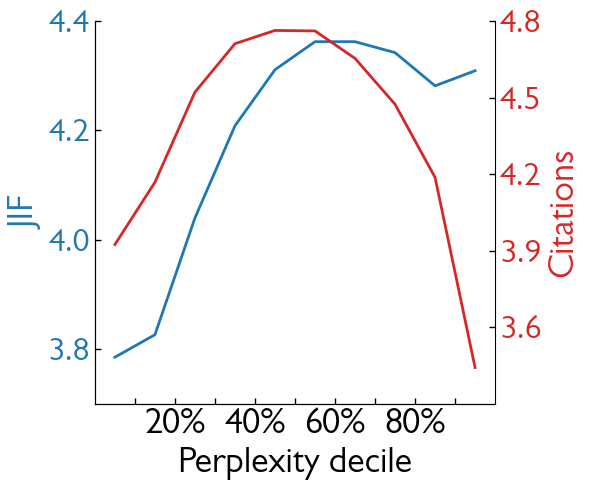

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

def process_file(file_path):
    df = pd.read_parquet(file_path)
    
    df['perplexity_bins'] = pd.qcut(df['perplexity'], 10)
    
    bin_stats = df.groupby('perplexity_bins').agg({
        'impact_factor_2y': 'mean',
        'citation': 'mean'
    }).reset_index()
    
    midpoints = []
    for interval in bin_stats['perplexity_bins']:
        left = df[df['perplexity'] <= interval.left]['perplexity'].count() / len(df) * 100
        right = df[df['perplexity'] <= interval.right]['perplexity'].count() / len(df) * 100
        midpoints.append((left + right) / 2)
    
    bin_stats['midpoints'] = midpoints
    
    return bin_stats['midpoints'].tolist(), bin_stats['impact_factor_2y'].tolist(), bin_stats['citation'].tolist()

file_paths = [
    "./ppl_jif_citation_olmo1b_natural_and_social_sciences.parquet",
    "./ppl_jif_citation_olmo7b_natural_and_social_sciences.parquet", 
    "./ppl_jif_citation_llama3_natural_and_social_sciences.parquet",
    "./ppl_jif_citation_deepseek_natural_and_social_sciences.parquet"
]

all_midpoints = []
all_impact_factors = []
all_cites = []

for i, file_path in enumerate(file_paths):
    model_name = file_path.split('/')[-2]
    
    midpoints, impact_factor, cites = process_file(file_path)
    
    all_midpoints.append(midpoints)
    all_impact_factors.append(impact_factor)
    all_cites.append(cites)

all_impact_factors = np.array(all_impact_factors)
all_cites = np.array(all_cites)
all_midpoints = np.array(all_midpoints)

avg_impact_factor = np.mean(all_impact_factors, axis=0)
avg_cites = np.mean(all_cites, axis=0)
avg_midpoints = np.mean(all_midpoints, axis=0)

blue_color = '#1f77b4'
red_color = '#d62728'

fig, ax1 = plt.subplots(figsize=(6, 5))

ax1.plot(avg_midpoints, avg_impact_factor, linestyle='-', color=blue_color, linewidth=2, label='Mean Impact Factor 2y')

ax1.set_xlabel('Perplexity decile', fontsize=26)
ax1.set_ylabel('JIF', fontsize=26, color=blue_color)
ax1.tick_params(axis='y', labelcolor=blue_color, labelsize=24)
ax1.set_xlim(0, 100)

ax1.set_ylim(3.7, 4.4)
ax1.set_yticks([3.8, 4.0, 4.2, 4.4])

ax2 = ax1.twinx()

ax2.plot(avg_midpoints, avg_cites, linestyle='-', color=red_color, linewidth=2, label='Mean 2y Citations')

ax2.set_ylabel('Citations', fontsize=26, color=red_color)
ax2.tick_params(axis='y', labelcolor=red_color, labelsize=24)

ax2.set_ylim(3.3, 4.8)
ax2.set_yticks([3.6, 3.9, 4.2, 4.5, 4.8])

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

ax1.tick_params(axis='both', which='both', direction='in', length=4, width=1)
ax2.tick_params(axis='y', direction='in', length=4, width=1)

x_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([
    "20%" if i == 20 else
    "40%" if i == 40 else
    "60%" if i == 60 else
    "80%" if i == 80 else
    ""
    for i in x_ticks
])
ax1.tick_params(axis='x', labelsize=26)

plt.tight_layout()
plt.show()


In [ ]:
# Fig. 4d

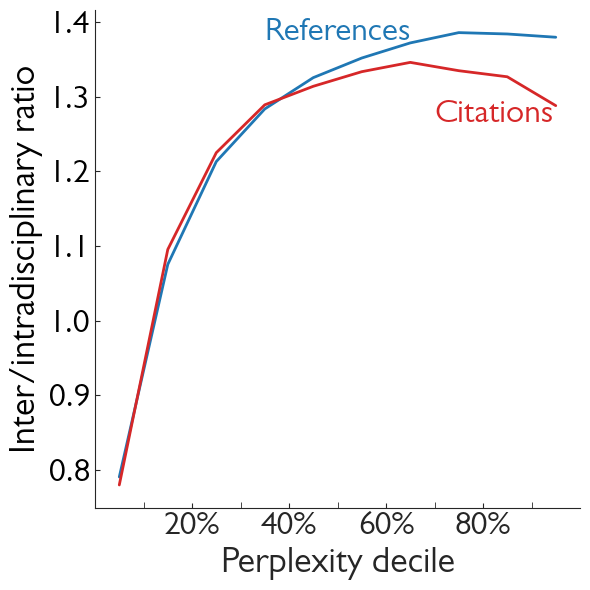

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

ref_file_path = "./4_ppl_interdisciplinary_reference_natural-and-social-science.parquet"
cit_file_path = "./4_ppl_interdisciplinary_citation_natural-and-social-science.parquet"

ppl_cols = ['perplexity_olmo1b', 'perplexity_olmo7b', 'perplexity_llama3', 'perplexity_deepseek']

def compute_curves_from_parquet(file_path, ppl_columns):
    df_raw = pd.read_parquet(file_path)
    curves = []
    
    for ppl_col in ppl_columns:
        df = df_raw.dropna(subset=[ppl_col]).copy()
        df_unique = df.drop_duplicates(subset='id').copy()
        
        perp_bins = pd.qcut(df_unique[ppl_col], q=10, retbins=True, duplicates='drop')[1]
        df['perp_bin'] = pd.cut(df[ppl_col], bins=perp_bins, include_lowest=True, labels=False)
        
        grouped = df.groupby(['perp_bin', 'interdisciplinary']).size().unstack(fill_value=0)
        
        for col in [0, 1]:
            if col not in grouped.columns:
                grouped[col] = 0
                
        grouped = grouped.sort_index()
        ratio = grouped[1] / (grouped[0] + 1e-8)
        
        curves.append(ratio.values)
        
    return np.array(curves)

reference_curves = compute_curves_from_parquet(ref_file_path, ppl_cols)
citation_curves = compute_curves_from_parquet(cit_file_path, ppl_cols)

reference_mean = reference_curves.mean(axis=0)
citation_mean = citation_curves.mean(axis=0)

x = np.arange(len(reference_mean)) + 0.5

fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

color_ref = 'tab:blue'
color_cit = 'tab:red'
ax.plot(x, reference_mean, color=color_ref, linewidth=2)
ax.plot(x, citation_mean, color=color_cit, linewidth=2)

ax.set_xlabel('Perplexity decile', fontsize=26)
ax.set_ylabel('Inter/intradisciplinary ratio', fontsize=26, color='black')
ax.tick_params(axis='y', labelcolor='black', direction='in', labelsize=24)
ax.tick_params(axis='x', direction='in', labelsize=24)

x_display_ticks = [2, 4, 6, 8]
x_labels = ['20%', '40%', '60%', '80%']
ax.set_xticks(x_display_ticks)
ax.set_xticklabels(x_labels)

minor_ticks = [1, 3, 5, 7, 9]
ax.set_xticks(minor_ticks, minor=True)
ax.tick_params(axis='x', which='minor', length=4, direction='in', labelbottom=False)

ax.set_xlim(0, 10)

ax.text(3.5, reference_mean[4] + 0.06, 'References', fontsize=24, color=color_ref, ha='left', va='center')
ax.text(7, citation_mean[6] - 0.07, 'Citations', fontsize=24, color=color_cit, ha='left', va='center')

plt.tight_layout()
plt.show()


In [ ]:
# Fig. 4e

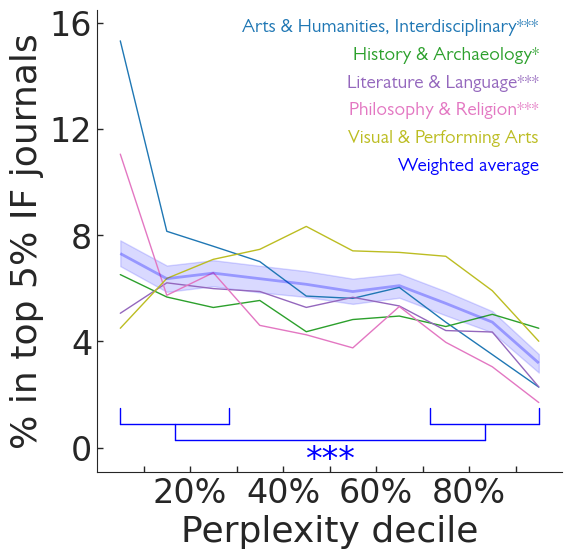

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import matplotlib
import matplotlib.font_manager as fm
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

data_dir = "./data_field/"
file_paths = glob.glob(os.path.join(data_dir, "*_perplexity1.parquet"))

cmap = matplotlib.colormaps.get_cmap("tab20")
colors = [cmap(i / len(file_paths)) for i in range(len(file_paths))]

label_mapping = {
    'arts_humanities_interdisciplinary': 'Arts & Humanities, Interdisciplinary***',
    'history_archaeology': 'History & Archaeology*',
    'literature_language': 'Literature & Language***',
    'philosophy_religion': 'Philosophy & Religion***',
    'visual_performing_arts': 'Visual & Performing Arts'
}

def bootstrap_confidence_interval(data, percentile=95, n_bootstrap=1000):
    if len(data) == 0:
        return 0, 0
    
    alpha = (100 - percentile) / 100
    
    bootstrap_samples = np.random.choice(data, size=(n_bootstrap, len(data)), replace=True)
    bootstrap_means = np.mean(bootstrap_samples, axis=1)
    
    lower_bound = np.percentile(bootstrap_means, alpha/2 * 100)
    upper_bound = np.percentile(bootstrap_means, (1 - alpha/2) * 100)
    
    return lower_bound, upper_bound

def bootstrap_confidence_interval_stratified(data_by_group, group_weights=None, percentile=95, n_bootstrap=1000):
    data_by_group = {group: data for group, data in data_by_group.items() if data}
    
    if not data_by_group:
        return 0, 0
    
    alpha = (100 - percentile) / 100
    
    if group_weights is None:
        group_weights = {group: 1/len(data_by_group) for group in data_by_group}
    
    total_weight = sum(group_weights[group] for group in data_by_group if group in group_weights)
    if total_weight > 0:
        normalized_weights = {group: weight/total_weight for group, weight in group_weights.items() 
                              if group in data_by_group}
    else:
        normalized_weights = {group: 1/len(data_by_group) for group in data_by_group}
    
    bootstrap_means = []
    for _ in range(n_bootstrap):
        group_means = {}
        for group, data in data_by_group.items():
            if data:
                resampled_data = np.random.choice(data, size=len(data), replace=True)
                group_means[group] = np.mean(resampled_data)
        
        weighted_mean = sum(group_means[group] * normalized_weights[group] for group in group_means)
        bootstrap_means.append(weighted_mean)
    
    lower_bound = np.percentile(bootstrap_means, alpha/2 * 100)
    upper_bound = np.percentile(bootstrap_means, (1 - alpha/2) * 100)
    
    return lower_bound, upper_bound

def plot_data(file_list, title_suffix, main_ax=None):
    if main_ax is None:
        plt.figure(figsize=(6, 6))
        main_ax = plt.gca()
    
    sns.set_style("ticks")
    
    legend_labels = []
    legend_colors = []
    
    all_bin_data = {bin_idx: [] for bin_idx in range(10)}
    all_y_values = []
    
    bin_data_by_file = {bin_idx: {} for bin_idx in range(10)}
    bin_weights = {bin_idx: {} for bin_idx in range(10)}
    
    for idx, file_path in enumerate(sorted(file_list)):
        df = pd.read_parquet(file_path)        
        filename = os.path.basename(file_path)
        group_name = filename.replace("_perplexity1.parquet", "")
        display_name = label_mapping.get(group_name, group_name)
        legend_labels.append(display_name)
        legend_colors.append(colors[idx])
        
        threshold_impact_factor = df['impact_factor_2y'].quantile(0.95)
        df['perplexity_bins'] = pd.qcut(df['perplexity'], 10, labels=False)
        percentages = []
        
        current_file_bootstrap_data = {bin_idx: [] for bin_idx in range(10)}
        
        for bin_idx in range(10):
            subset = df[df['perplexity_bins'] == bin_idx]
            bin_count = len(subset)
            
            if bin_count > 0:
                top_5_percent_impact_factor = subset[subset['impact_factor_2y'] >= threshold_impact_factor]
                percentage = len(top_5_percent_impact_factor) / bin_count * 100
                
                is_top_5_percent = np.zeros(bin_count)
                is_top_5_percent[:len(top_5_percent_impact_factor)] = 1
                np.random.shuffle(is_top_5_percent)
                
                all_bin_data[bin_idx].extend(is_top_5_percent * 100)
                
                bin_data_by_file[bin_idx][group_name] = list(is_top_5_percent * 100)
                bin_weights[bin_idx][group_name] = bin_count
                
                current_file_bootstrap_data[bin_idx] = list(is_top_5_percent * 100)
            else:
                percentage = 0
                bin_data_by_file[bin_idx][group_name] = []
                bin_weights[bin_idx][group_name] = 0
                current_file_bootstrap_data[bin_idx] = []
            
            mid_percent = (bin_idx + 0.5) * 10
            percentages.append((mid_percent, percentage))
        
        x_values = [x[0] for x in percentages]
        y_values = [x[1] for x in percentages]
        all_y_values.extend(y_values)
        
        main_ax.plot(x_values, y_values, color=colors[idx], linestyle='-', linewidth=1, alpha=1, label=display_name)
    
    weighted_avg_values = []
    
    for bin_idx in range(10):
        total_weight = sum(bin_weights[bin_idx].values())
        if total_weight > 0:
            weights = {group: count/total_weight for group, count in bin_weights[bin_idx].items()}
            weighted_mean = 0
            for group in bin_data_by_file[bin_idx]:
                if bin_data_by_file[bin_idx][group] and len(bin_data_by_file[bin_idx][group]) > 0:
                    group_mean = np.mean(bin_data_by_file[bin_idx][group])
                    weighted_mean += group_mean * weights[group]
            
            weighted_avg_values.append(weighted_mean)
        else:
            weighted_avg_values.append(0)
    
    weighted_avg_lower_bounds = []
    weighted_avg_upper_bounds = []
    for bin_idx in range(10):
        if bin_data_by_file[bin_idx]:
            weights_for_bootstrap = {group: bin_weights[bin_idx][group] for group in bin_data_by_file[bin_idx]}
            lower, upper = bootstrap_confidence_interval_stratified(
                bin_data_by_file[bin_idx], 
                group_weights=weights_for_bootstrap, 
                percentile=95, 
                n_bootstrap=1000
            )
            weighted_avg_lower_bounds.append(lower)
            weighted_avg_upper_bounds.append(upper)
        else:
            weighted_avg_lower_bounds.append(0)
            weighted_avg_upper_bounds.append(0)
    
    x_values_avg = [(bin_idx + 0.5) * 10 for bin_idx in range(10)]
    all_y_values.extend(weighted_avg_values)
    all_y_values.extend(weighted_avg_lower_bounds)
    all_y_values.extend(weighted_avg_upper_bounds)
    
    main_ax.fill_between(x_values_avg, weighted_avg_lower_bounds, weighted_avg_upper_bounds, color='blue', alpha=0.15)
    
    main_ax.plot(x_values_avg, weighted_avg_values, color='blue', linestyle='-', linewidth=2, alpha=0.3, label='Weighted average', solid_capstyle='butt')
    
    y_min_bottom = min(all_y_values)
    y_base_lower = y_min_bottom - 0.2
    
    lower_left_bracket_width = 23.33
    lower_right_bracket_width = 23.33
    lower_bracket_height = 0.6
    lower_top_bracket_height = 0.6
    lower_vertical_gap = 0
    
    x_left_center = 16.665
    x_right_center = 83.335
    
    x_left_start_lower = x_left_center - lower_left_bracket_width/2
    x_left_end_lower = x_left_center + lower_left_bracket_width/2
    x_right_start_lower = x_right_center - lower_right_bracket_width/2
    x_right_end_lower = x_right_center + lower_right_bracket_width/2
    
    main_ax.plot([x_left_start_lower, x_left_start_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')
    main_ax.plot([x_left_start_lower, x_left_end_lower], [y_base_lower - lower_bracket_height, y_base_lower - lower_bracket_height], linewidth=1, color='blue')
    main_ax.plot([x_left_end_lower, x_left_end_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')
    
    main_ax.plot([x_right_start_lower, x_right_start_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')
    main_ax.plot([x_right_start_lower, x_right_end_lower], [y_base_lower - lower_bracket_height, y_base_lower - lower_bracket_height], linewidth=1, color='blue')
    main_ax.plot([x_right_end_lower, x_right_end_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')
    
    y_top_base_lower = y_base_lower - lower_bracket_height - lower_vertical_gap
    y_top_top_lower = y_top_base_lower - lower_top_bracket_height
    
    main_ax.plot([x_left_center, x_left_center], [y_base_lower - lower_bracket_height, y_top_base_lower], linewidth=1, color='blue')
    main_ax.plot([x_right_center, x_right_center], [y_base_lower - lower_bracket_height, y_top_base_lower], linewidth=1, color='blue')
    
    main_ax.plot([x_left_center, x_left_center], [y_top_base_lower, y_top_top_lower], linewidth=1, color='blue')
    main_ax.plot([x_left_center, x_right_center], [y_top_top_lower, y_top_top_lower], linewidth=1, color='blue')
    main_ax.plot([x_right_center, x_right_center], [y_top_top_lower, y_top_base_lower], linewidth=1, color='blue')
    
    main_ax.text((x_left_center + x_right_center) / 2, y_top_top_lower - 0.15, "***", 
                 ha='center', va='top', fontsize=24, color='blue')
    
    x_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
    main_ax.set_xticks(x_ticks)
    main_ax.set_xticklabels([
        "20%" if i == 20 else
        "40%" if i == 40 else
        "60%" if i == 60 else
        "80%" if i == 80 else
        ""
        for i in x_ticks
    ])
    
    main_ax.set_xlim(0, 100)
    
    main_ax.set_xlabel("Perplexity decile", fontsize=26)
    main_ax.set_ylabel("% in top 5% IF journals", fontsize=26)
    
    main_ax.spines['top'].set_visible(False)
    main_ax.spines['right'].set_visible(False)
    main_ax.tick_params(axis='both', which='both', direction='in', length=4, width=1)
    
    y_plot_min = min(y_top_top_lower - 0.3, min(all_y_values) - 1)
    y_plot_max = max(all_y_values) + 0.5
    main_ax.set_ylim(y_plot_min, y_plot_max)
    
    main_ax.tick_params(axis='both', labelsize=24)
    
    main_ax.set_ylim(-0.9, 16.5)
    main_ax.set_yticks([0, 4, 8, 12, 16])
    
    main_ax.grid(False)
    
    legend_labels.append('Weighted average')
    legend_colors.append('blue')
    
    legend_x = 0.95
    legend_y = 0.98
    legend_spacing = 0.06
    
    for i, (label, color) in enumerate(zip(legend_labels, legend_colors)):
        y_pos = legend_y - i * legend_spacing
        main_ax.text(legend_x, y_pos, label, 
                    transform=main_ax.transAxes,
                    fontsize=14, 
                    color=color,
                    ha='right', va='top')

fig, ax1 = plt.subplots(1, 1, figsize=(6, 6))

plot_data(file_paths, "All Files", ax1)

plt.show()

In [ ]:
# Fig. 4f

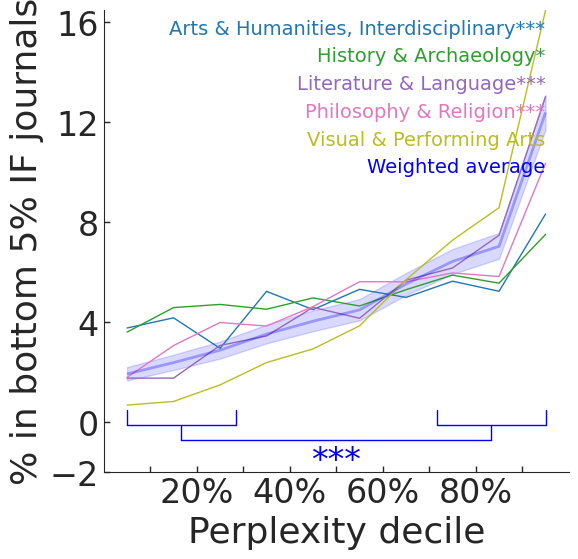

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import matplotlib
import matplotlib.font_manager as fm
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

data_dir = "./data_field/"
file_paths = glob.glob(os.path.join(data_dir, "*_perplexity1.parquet"))

cmap = matplotlib.colormaps.get_cmap("tab20")
colors = [cmap(i / len(file_paths)) for i in range(len(file_paths))]

label_mapping = {
    'arts_humanities_interdisciplinary': 'Arts & Humanities, Interdisciplinary***',
    'history_archaeology': 'History & Archaeology*',
    'literature_language': 'Literature & Language***',
    'philosophy_religion': 'Philosophy & Religion***',
    'visual_performing_arts': 'Visual & Performing Arts'
}

def bootstrap_confidence_interval(data, percentile=95, n_bootstrap=1000):
    if len(data) == 0:
        return 0, 0
    
    alpha = (100 - percentile) / 100
    
    bootstrap_samples = np.random.choice(data, size=(n_bootstrap, len(data)), replace=True)
    bootstrap_means = np.mean(bootstrap_samples, axis=1)
    
    lower_bound = np.percentile(bootstrap_means, alpha/2 * 100)
    upper_bound = np.percentile(bootstrap_means, (1 - alpha/2) * 100)
    
    return lower_bound, upper_bound

def bootstrap_confidence_interval_stratified(data_by_group, group_weights=None, percentile=95, n_bootstrap=1000):
    data_by_group = {group: data for group, data in data_by_group.items() if data}
    
    if not data_by_group:
        return 0, 0
    
    alpha = (100 - percentile) / 100
    
    if group_weights is None:
        group_weights = {group: 1/len(data_by_group) for group in data_by_group}
    
    total_weight = sum(group_weights[group] for group in data_by_group if group in group_weights)
    if total_weight > 0:
        normalized_weights = {group: weight/total_weight for group, weight in group_weights.items() 
                              if group in data_by_group}
    else:
        normalized_weights = {group: 1/len(data_by_group) for group in data_by_group}
    
    bootstrap_means = []
    for _ in range(n_bootstrap):
        group_means = {}
        for group, data in data_by_group.items():
            if data:
                resampled_data = np.random.choice(data, size=len(data), replace=True)
                group_means[group] = np.mean(resampled_data)
        
        weighted_mean = sum(group_means[group] * normalized_weights[group] for group in group_means)
        bootstrap_means.append(weighted_mean)
    
    lower_bound = np.percentile(bootstrap_means, alpha/2 * 100)
    upper_bound = np.percentile(bootstrap_means, (1 - alpha/2) * 100)
    
    return lower_bound, upper_bound

def plot_data(file_list, title_suffix, main_ax=None):
    if main_ax is None:
        plt.figure(figsize=(6, 6))
        main_ax = plt.gca()
    
    sns.set_style("ticks")
    
    legend_labels = []
    legend_colors = []
    
    all_bin_data = {bin_idx: [] for bin_idx in range(10)}
    all_y_values = []
    
    bin_data_by_file = {bin_idx: {} for bin_idx in range(10)}
    bin_weights = {bin_idx: {} for bin_idx in range(10)}
    
    for idx, file_path in enumerate(sorted(file_list)):
        df = pd.read_parquet(file_path)        
        filename = os.path.basename(file_path)
        group_name = filename.replace("_perplexity1.parquet", "")
        display_name = label_mapping.get(group_name, group_name)
        legend_labels.append(display_name)
        legend_colors.append(colors[idx])
        
        threshold_impact_factor = df['impact_factor_2y'].quantile(0.05)
        df['perplexity_bins'] = pd.qcut(df['perplexity'], 10, labels=False)
        percentages = []
        
        current_file_bootstrap_data = {bin_idx: [] for bin_idx in range(10)}
        
        for bin_idx in range(10):
            subset = df[df['perplexity_bins'] == bin_idx]
            bin_count = len(subset)
            
            if bin_count > 0:
                top_5_percent_impact_factor = subset[subset['impact_factor_2y'] <= threshold_impact_factor]
                percentage = len(top_5_percent_impact_factor) / bin_count * 100
                
                is_top_5_percent = np.zeros(bin_count)
                is_top_5_percent[:len(top_5_percent_impact_factor)] = 1
                np.random.shuffle(is_top_5_percent)
                
                all_bin_data[bin_idx].extend(is_top_5_percent * 100)
                
                bin_data_by_file[bin_idx][group_name] = list(is_top_5_percent * 100)
                bin_weights[bin_idx][group_name] = bin_count
                
                current_file_bootstrap_data[bin_idx] = list(is_top_5_percent * 100)
            else:
                percentage = 0
                bin_data_by_file[bin_idx][group_name] = []
                bin_weights[bin_idx][group_name] = 0
                current_file_bootstrap_data[bin_idx] = []
            
            mid_percent = (bin_idx + 0.5) * 10
            percentages.append((mid_percent, percentage))
        
        x_values = [x[0] for x in percentages]
        y_values = [x[1] for x in percentages]
        all_y_values.extend(y_values)
        
        main_ax.plot(x_values, y_values, color=colors[idx], linestyle='-', linewidth=1, alpha=1, label=display_name)
    
    weighted_avg_values = []
    
    for bin_idx in range(10):
        total_weight = sum(bin_weights[bin_idx].values())
        if total_weight > 0:
            weights = {group: count/total_weight for group, count in bin_weights[bin_idx].items()}
            weighted_mean = 0
            for group in bin_data_by_file[bin_idx]:
                if bin_data_by_file[bin_idx][group] and len(bin_data_by_file[bin_idx][group]) > 0:
                    group_mean = np.mean(bin_data_by_file[bin_idx][group])
                    weighted_mean += group_mean * weights[group]
            
            weighted_avg_values.append(weighted_mean)
        else:
            weighted_avg_values.append(0)
    
    weighted_avg_lower_bounds = []
    weighted_avg_upper_bounds = []
    for bin_idx in range(10):
        if bin_data_by_file[bin_idx]:
            weights_for_bootstrap = {group: bin_weights[bin_idx][group] for group in bin_data_by_file[bin_idx]}
            lower, upper = bootstrap_confidence_interval_stratified(
                bin_data_by_file[bin_idx], 
                group_weights=weights_for_bootstrap, 
                percentile=95, 
                n_bootstrap=1000
            )
            weighted_avg_lower_bounds.append(lower)
            weighted_avg_upper_bounds.append(upper)
        else:
            weighted_avg_lower_bounds.append(0)
            weighted_avg_upper_bounds.append(0)
    
    x_values_avg = [(bin_idx + 0.5) * 10 for bin_idx in range(10)]
    all_y_values.extend(weighted_avg_values)
    all_y_values.extend(weighted_avg_lower_bounds)
    all_y_values.extend(weighted_avg_upper_bounds)
    
    main_ax.fill_between(x_values_avg, weighted_avg_lower_bounds, weighted_avg_upper_bounds, color='blue', alpha=0.15)
    
    main_ax.plot(x_values_avg, weighted_avg_values, color='blue', linestyle='-', linewidth=2, alpha=0.3, label='Weighted average', solid_capstyle='butt')
    
    y_min_bottom = min(all_y_values)
    y_base_lower = y_min_bottom - 0.2
    
    lower_left_bracket_width = 23.33
    lower_right_bracket_width = 23.33
    lower_bracket_height = 0.6
    lower_top_bracket_height = 0.6
    lower_vertical_gap = 0
    
    x_left_center = 16.665
    x_right_center = 83.335
    
    x_left_start_lower = x_left_center - lower_left_bracket_width/2
    x_left_end_lower = x_left_center + lower_left_bracket_width/2
    x_right_start_lower = x_right_center - lower_right_bracket_width/2
    x_right_end_lower = x_right_center + lower_right_bracket_width/2
    
    main_ax.plot([x_left_start_lower, x_left_start_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')
    main_ax.plot([x_left_start_lower, x_left_end_lower], [y_base_lower - lower_bracket_height, y_base_lower - lower_bracket_height], linewidth=1, color='blue')
    main_ax.plot([x_left_end_lower, x_left_end_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')
    
    main_ax.plot([x_right_start_lower, x_right_start_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')
    main_ax.plot([x_right_start_lower, x_right_end_lower], [y_base_lower - lower_bracket_height, y_base_lower - lower_bracket_height], linewidth=1, color='blue')
    main_ax.plot([x_right_end_lower, x_right_end_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='blue')
    
    y_top_base_lower = y_base_lower - lower_bracket_height - lower_vertical_gap
    y_top_top_lower = y_top_base_lower - lower_top_bracket_height
    
    main_ax.plot([x_left_center, x_left_center], [y_base_lower - lower_bracket_height, y_top_base_lower], linewidth=1, color='blue')
    main_ax.plot([x_right_center, x_right_center], [y_base_lower - lower_bracket_height, y_top_base_lower], linewidth=1, color='blue')
    
    main_ax.plot([x_left_center, x_left_center], [y_top_base_lower, y_top_top_lower], linewidth=1, color='blue')
    main_ax.plot([x_left_center, x_right_center], [y_top_top_lower, y_top_top_lower], linewidth=1, color='blue')
    main_ax.plot([x_right_center, x_right_center], [y_top_top_lower, y_top_base_lower], linewidth=1, color='blue')
    
    main_ax.text((x_left_center + x_right_center) / 2, y_top_top_lower - 0.15, "***", 
                 ha='center', va='top', fontsize=24, color='blue')
    
    x_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
    main_ax.set_xticks(x_ticks)
    main_ax.set_xticklabels([
        "20%" if i == 20 else
        "40%" if i == 40 else
        "60%" if i == 60 else
        "80%" if i == 80 else
        ""
        for i in x_ticks
    ])
    
    main_ax.set_xlim(0, 100)
    
    main_ax.set_xlabel("Perplexity decile", fontsize=26)
    main_ax.set_ylabel("% in bottom 5% IF journals", fontsize=26)
    
    main_ax.spines['top'].set_visible(False)
    main_ax.spines['right'].set_visible(False)
    main_ax.tick_params(axis='both', which='both', direction='in', length=4, width=1)
    
    y_plot_min = min(y_top_top_lower - 0.3, min(all_y_values) - 1)
    y_plot_max = max(all_y_values) + 0.5
    main_ax.set_ylim(y_plot_min, y_plot_max)
    
    main_ax.tick_params(axis='both', labelsize=24)
    
    main_ax.set_ylim(-0.9, 16.5)
    main_ax.set_yticks([-2, 0, 4, 8, 12, 16])
    
    main_ax.grid(False)
    
    legend_labels.append('Weighted average')
    legend_colors.append('blue')
    
    legend_x = 0.95
    legend_y = 0.98
    legend_spacing = 0.06
    
    for i, (label, color) in enumerate(zip(legend_labels, legend_colors)):
        y_pos = legend_y - i * legend_spacing
        main_ax.text(legend_x, y_pos, label, 
                    transform=main_ax.transAxes,
                    fontsize=14, 
                    color=color,
                    ha='right', va='top')

fig, ax1 = plt.subplots(1, 1, figsize=(6, 6))

plot_data(file_paths, "All Files", ax1)

plt.show()

In [ ]:
# Fig. 4g

/scratch/local/jobs/59349233/ipykernel_1251198/2673755710.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df.groupby('perplexity_bins').agg({
/scratch/local/jobs/59349233/ipykernel_1251198/2673755710.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df.groupby('perplexity_bins').agg({
/scratch/local/jobs/59349233/ipykernel_1251198/2673755710.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warnin

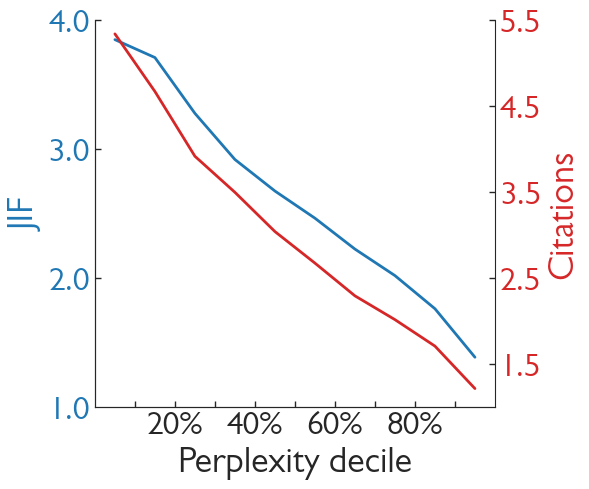

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.ticker as mticker

def process_file(file_path):
    df = pd.read_parquet(file_path)
    
    df['perplexity_bins'] = pd.qcut(df['perplexity'], 10)
    
    bin_stats = df.groupby('perplexity_bins').agg({
        'impact_factor_2y': 'mean',
        'citation': 'mean'
    }).reset_index()
    
    midpoints = []
    for interval in bin_stats['perplexity_bins']:
        left = df[df['perplexity'] <= interval.left]['perplexity'].count() / len(df) * 100
        right = df[df['perplexity'] <= interval.right]['perplexity'].count() / len(df) * 100
        midpoints.append((left + right) / 2)
    
    bin_stats['midpoints'] = midpoints
    
    return bin_stats['midpoints'].tolist(), bin_stats['impact_factor_2y'].tolist(), bin_stats['citation'].tolist()

file_paths = [
    "./ppl_jif_citation_olmo1b_arts_and_humanities.parquet",
    "./ppl_jif_citation_olmo7b_arts_and_humanities.parquet", 
    "./ppl_jif_citation_llama3_arts_and_humanities.parquet",
    "./ppl_jif_citation_deepseek_arts_and_humanities.parquet"
]

all_midpoints = []
all_impact_factors = []
all_cites = []

for i, file_path in enumerate(file_paths):
    model_name = file_path.split('/')[-2]
    
    midpoints, impact_factor, cites = process_file(file_path)
    
    all_midpoints.append(midpoints)
    all_impact_factors.append(impact_factor)
    all_cites.append(cites)

all_impact_factors = np.array(all_impact_factors)
all_cites = np.array(all_cites)
all_midpoints = np.array(all_midpoints)

avg_impact_factor = np.mean(all_impact_factors, axis=0)
avg_cites = np.mean(all_cites, axis=0)
avg_midpoints = np.mean(all_midpoints, axis=0)

blue_color = '#1f77b4'
red_color = '#d62728'

fig, ax1 = plt.subplots(figsize=(6, 5))

ax1.plot(avg_midpoints, avg_impact_factor, linestyle='-', color=blue_color, linewidth=2, label='Mean Impact Factor 2y')

ax1.set_xlabel('Perplexity decile', fontsize=26)
ax1.set_ylabel('JIF', fontsize=26, color=blue_color)
ax1.tick_params(axis='y', labelcolor=blue_color, labelsize=24)
ax1.set_xlim(0, 100)

ax1.set_ylim(1, 4)
ax1.set_yticks([1.0, 2.0, 3.0, 4.0])
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
ax1.tick_params(axis='y', which='major', direction='in', length=4, width=1)

ax1_yticks = ax1.yaxis.get_major_ticks()
ax1_yticks[0].tick1line.set_visible(False)

ax2 = ax1.twinx()

ax2.plot(avg_midpoints, avg_cites, linestyle='-', color=red_color, linewidth=2, label='Mean 2y Citations')

ax2.set_ylabel('Citations', fontsize=26, color=red_color)
ax2.tick_params(axis='y', labelcolor=red_color, labelsize=24)

ax2.set_ylim(1, 5.5)
ax2.set_yticks([1.5, 2.5, 3.5, 4.5, 5.5])

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

ax1.tick_params(axis='x', which='both', direction='in', length=4, width=1)
ax2.tick_params(axis='y', direction='in', length=4, width=1)

ax1_yticks = ax1.yaxis.get_major_ticks()
ax1_yticks[0].tick1line.set_visible(False)

x_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([
    "20%" if i == 20 else
    "40%" if i == 40 else
    "60%" if i == 60 else
    "80%" if i == 80 else
    ""
    for i in x_ticks
])
ax1.tick_params(axis='x', labelsize=24)

plt.tight_layout()
plt.show()


In [ ]:
# Fig. 4h

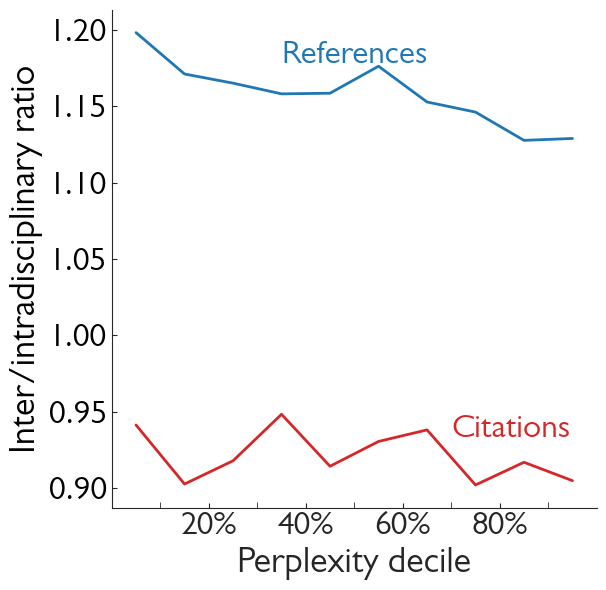

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

ref_file_path = "./4_ppl_interdisciplinary_reference_art-and-humanities.parquet"
cit_file_path = "./4_ppl_interdisciplinary_citation_art-and-humanities.parquet"

ppl_cols = ['perplexity_olmo1b', 'perplexity_olmo7b', 'perplexity_llama3', 'perplexity_deepseek']

def compute_curves_from_parquet(file_path, ppl_columns):
    df_raw = pd.read_parquet(file_path)
    curves = []

    for ppl_col in ppl_columns:
        df = df_raw.dropna(subset=[ppl_col]).copy()

        df_unique = df.drop_duplicates(subset='id').copy()

        perp_bins = pd.qcut(df_unique[ppl_col], q=10, retbins=True, duplicates='drop')[1]

        df['perp_bin'] = pd.cut(df[ppl_col], bins=perp_bins, include_lowest=True, labels=False)

        grouped = df.groupby(['perp_bin', 'interdisciplinary']).size().unstack(fill_value=0)

        for col in [0, 1]:
            if col not in grouped.columns:
                grouped[col] = 0

        grouped = grouped.sort_index()
        ratio = grouped[1] / (grouped[0] + 1e-8)

        curves.append(ratio.values)

    return np.array(curves)

reference_curves = compute_curves_from_parquet(ref_file_path, ppl_cols)
citation_curves = compute_curves_from_parquet(cit_file_path, ppl_cols)

reference_mean = reference_curves.mean(axis=0)
citation_mean = citation_curves.mean(axis=0)

x = np.arange(len(reference_mean)) + 0.5

fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

color_ref = 'tab:blue'
color_cit = 'tab:red'
ax.plot(x, reference_mean, color=color_ref, linewidth=2)
ax.plot(x, citation_mean, color=color_cit, linewidth=2)

ax.set_xlabel('Perplexity decile', fontsize=26)
ax.set_ylabel('Inter/intradisciplinary ratio', fontsize=26, color='black')
ax.tick_params(axis='y', labelcolor='black', direction='in', labelsize=24)
ax.tick_params(axis='x', direction='in', labelsize=24)

x_display_ticks = [2, 4, 6, 8]
x_labels = ['20%', '40%', '60%', '80%']
ax.set_xticks(x_display_ticks)
ax.set_xticklabels(x_labels)

minor_ticks = [1, 3, 5, 7, 9]
ax.set_xticks(minor_ticks, minor=True)
ax.tick_params(axis='x', which='minor', length=4, direction='in', labelbottom=False)

ax.set_xlim(0, 10)

ax.text(3.5, reference_mean[4] + 0.025, 'References', fontsize=24, color=color_ref, ha='left', va='center')
ax.text(7, citation_mean[6], 'Citations', fontsize=24, color=color_cit, ha='left', va='center')

plt.tight_layout()
plt.show()